In [2]:
import sys
sys.path.insert(0, '/home/bnc2119/MEDAL')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from src.medal.eval_utils import load_and_split, get_teacher_embeddings
from src.medal.core import AutoEncoder
import torch
import matplotlib.colors as mcolors
from pathlib import Path
import matplotlib.ticker as ticker
from sklearn.model_selection import train_test_split
from sklearn.metrics import jaccard_score
PATH_PREFIX = '/share/ctn/users/bnc2119' 
%load_ext autoreload
%autoreload 2

/home/bnc2119/.conda/envs/medal/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-19 00:33:37,353	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-03-19 00:33:38,356	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [3]:
def load_trained_ae(ckpt_path, input_dim, hidden_dims,activation=torch.nn.SELU, latent_dim=2, batchnorm=False):
    import sys, os
    old_stdout = sys.stdout
    sys.stdout = open(os.devnull, "w")
    model = AutoEncoder(
        input_dim=input_dim,
        latent_dim=latent_dim,
        hidden_dims=hidden_dims,
        activation=activation,            
        bottleneck_activation=None,
        use_batchnorm = batchnorm
    )
    sys.stdout = old_stdout

    sd = torch.load(ckpt_path, map_location="cpu")

    # unwrap to the real state dict
    if isinstance(sd, dict) and "model" in sd and isinstance(sd["model"], dict):
        sd = sd["model"]
    elif isinstance(sd, dict) and "state_dict" in sd and isinstance(sd["state_dict"], dict):
        sd = sd["state_dict"]

    # remove DDP prefixes if any
    sd = {k.replace("module.", ""): v for k, v in sd.items()}

    # load STRICTLY so we fail fast if something doesn’t match
    missing, unexpected = model.load_state_dict(sd, strict=False)
    print(f"loaded params: {len(sd)} | missing={len(missing)} | unexpected={len(unexpected)}")
    if missing or unexpected:
        print("⚠️ Check architecture/keys. Example missing:", missing[:3], "unexpected:", unexpected[:3])

    model.eval()
    return model

def split_scdeed_labels(df, best_param):
    result = []
    for l in ["dubious", "trustworthy", "intermediate"]:
        vec = df.loc[best_param, f"{l}_cells"]
        ls_indices = np.array(vec.split(',')).astype(int)
        result.extend(list(zip([l]* len(ls_indices), ls_indices)))
    return pd.DataFrame(result, columns = ['label', 'index']).set_index('index').sort_index()

import numpy as np

def jaccard_curve(scores_runs, quantiles):

    jaccard_curve = []
    core_curve = []

    for q in quantiles:
        threshold_sets = [scores_runs[s] >= np.quantile(scores_runs[s], q) for s in scores_runs]

        inter = np.logical_and.reduce(threshold_sets).sum()
        union = np.logical_or.reduce(threshold_sets).sum()
        set_sizes = np.array([x.sum() for x in threshold_sets], dtype=float)
        mean_set_size = set_sizes.mean()

        print(f"q={q:0.3f}, inter={inter}, union={union}, mean_set_size={mean_set_size:.1f}")

        j3 = inter / union if union > 0 else 0.0
        core = inter / mean_set_size if mean_set_size > 0 else 0.0

        jaccard_curve.append(j3)
        core_curve.append(core)

    return np.array(jaccard_curve), np.array(core_curve)

## MNIST

In [13]:
X_og, X_test, y_og, y_test = load_and_split("mnist", test_size=0.2, seed=0, labels=True)
X, X_val, y, y_val = train_test_split(X_og, y_og, test_size=0.2, random_state=0)
label_colors = [plt.get_cmap("tab20")(i) for i in range(10)]
mnist_palette = {digit: col for digit, col in zip(y.value_counts().index, label_colors)}
cmap = sns.color_palette("BuGn", as_cmap=True)

In [86]:
tsne_param_sweep = [    5,    11,    27,    62,   146,   341,   793,  1846]
per_sample_recon_medal_all_tsne = {perp: {} for perp in tsne_param_sweep}
per_sample_recon_scdeed_all_tsne = {perp: {} for perp in tsne_param_sweep}
per_sample_recon_embedr_all_tsne = {perp: {} for perp in tsne_param_sweep}
per_sample_recon_pcs_all_tsne = {perp: {} for perp in tsne_param_sweep}
for s in [0, 2, 10]:
    pcs_df = pd.read_csv(Path(PATH_PREFIX) / f'MEDAL/comparisons/results_pcs_seed{s}/mnist_train/scores_per_point_all_perplexities.csv', index_col=0)
    scdeed_df = pd.read_csv(Path(PATH_PREFIX) / f"MEDAL/comparisons/results_scdeed_tsne/seed{s}/tsne_best_mnist_train_full_results.csv", index_col=0)
    embedr_df = pd.read_csv(Path(PATH_PREFIX) / f'MEDAL/comparisons/results_embedr_tsne_seed{s}/mnist_train/scores_per_point_all_perplexities.csv', index_col=0)
    for perp in tsne_param_sweep:
        teacher_embed = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/mnist_tsne_{perp}_{s}_train.npy")
        student = load_trained_ae(Path(PATH_PREFIX) / f"drd_data/tmp_results/chkpt_teacher_seed/mnist/medal_tsne2_{perp}_tc5_{s}_ckpts/final.pt",
                input_dim=784,
                hidden_dims=[512, 512, 512, 512],
                latent_dim=2, activation=torch.nn.SELU, batchnorm=False)
        
        student_recon, student_embed = student(torch.tensor(X, dtype=torch.float32))
        train_distill = np.mean((teacher_embed - student_embed.detach().numpy()) ** 2)
        if train_distill < 1e-5:
            per_sample_recon = np.mean((student_recon.detach().numpy() - X)**2, axis=1)
            per_sample_recon_medal_all_tsne[perp][s] = per_sample_recon
        
        per_sample_scdeed = split_scdeed_labels(scdeed_df, perp)['label']
        per_sample_recon_scdeed_all_tsne[perp][s] = per_sample_scdeed == "dubious"
        per_sample_embedr = embedr_df.loc[perp, 'embedr_pval']
        per_sample_recon_embedr_all_tsne[perp][s] = per_sample_embedr
        per_sample_pcs = pcs_df.loc[perp, 'sscore']
        per_sample_recon_pcs_all_tsne[perp][s] = per_sample_pcs
    

/tmp/ipykernel_24534/3795533998.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0


/tmp/ipykernel_24534/3795533998.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0


/tmp/ipykernel_24534/3795533998.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0


In [10]:
from itertools import combinations
from scipy.stats import spearmanr
# ---------------------------
# Pairwise Spearman rank correlation across runs
# ---------------------------
def summarize_rank_correlation(score_dict):
    """
    score_dict format:
      score_dict[hyperparam][seed] = 1D np.ndarray of scores
    """
    rows = []

    for hp, seed_to_scores in score_dict.items():
        available_seeds = sorted(seed_to_scores.keys())
        for s1, s2 in combinations(available_seeds, 2):
            rho, pval = spearmanr(seed_to_scores[s1], seed_to_scores[s2])
            rows.append({
                "hyperparam": hp,
                "seed1": s1,
                "seed2": s2,
                "spearman_rho": rho,
                "spearman_pval": pval
            })

    pairwise_df = pd.DataFrame(rows)

    summary_df = (
        pairwise_df
        .groupby("hyperparam", as_index=False)["spearman_rho"]
        .agg(["mean", "std", "count"])
        .reset_index()
        .rename(columns={
            "mean": "mean_pairwise_spearman",
            "std": "std_pairwise_spearman",
            "count": "n_pairs"
        })
    )

    return pairwise_df, summary_df

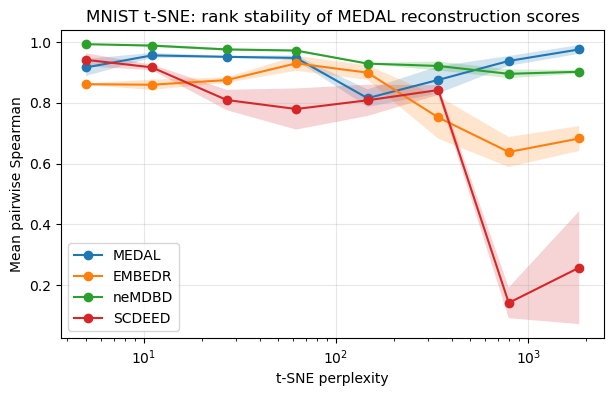

In [89]:
medal_pairwise_spearman_df, medal_mean_spearman_by_perp = summarize_rank_correlation(
    per_sample_recon_medal_all_tsne
)
embedr_pairwise_spearman_df, embedr_mean_spearman_by_perp = summarize_rank_correlation(
    per_sample_recon_embedr_all_tsne
)

pcs_pairwise_spearman_df, pcs_mean_spearman_by_perp = summarize_rank_correlation(
    per_sample_recon_pcs_all_tsne
)
scdeed_pairwise_spearman_df, scdeed_mean_spearman_by_perp = summarize_rank_correlation(
    per_sample_recon_scdeed_all_tsne
)

plt.figure(figsize=(7, 4))
plt.plot(
    medal_mean_spearman_by_perp["hyperparam"],
    medal_mean_spearman_by_perp["mean_pairwise_spearman"],
    marker="o", label = 'MEDAL'
)
plt.plot(
    embedr_mean_spearman_by_perp["hyperparam"],
    embedr_mean_spearman_by_perp["mean_pairwise_spearman"],
    marker="o", label = 'EMBEDR'
)
plt.plot(
    pcs_mean_spearman_by_perp["hyperparam"],
    pcs_mean_spearman_by_perp["mean_pairwise_spearman"],
    marker="o", label = 'neMDBD'
)
plt.plot(
    scdeed_mean_spearman_by_perp["hyperparam"],
    scdeed_mean_spearman_by_perp["mean_pairwise_spearman"],
    marker="o", label = 'SCDEED'
)

plt.fill_between(
    medal_mean_spearman_by_perp["hyperparam"],
    medal_mean_spearman_by_perp["mean_pairwise_spearman"] - medal_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    medal_mean_spearman_by_perp["mean_pairwise_spearman"] + medal_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    alpha=0.2
)
plt.fill_between(
    embedr_mean_spearman_by_perp["hyperparam"],
    embedr_mean_spearman_by_perp["mean_pairwise_spearman"] - embedr_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    embedr_mean_spearman_by_perp["mean_pairwise_spearman"] + embedr_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    alpha=0.2
)
plt.fill_between(
    pcs_mean_spearman_by_perp["hyperparam"],
    pcs_mean_spearman_by_perp["mean_pairwise_spearman"] - pcs_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    pcs_mean_spearman_by_perp["mean_pairwise_spearman"] + pcs_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    alpha=0.2
)
plt.fill_between(
    scdeed_mean_spearman_by_perp["hyperparam"],
    scdeed_mean_spearman_by_perp["mean_pairwise_spearman"] - scdeed_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    scdeed_mean_spearman_by_perp["mean_pairwise_spearman"] + scdeed_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    alpha=0.2
)
plt.xscale("log")
plt.legend()
plt.xlabel("t-SNE perplexity")
plt.ylabel("Mean pairwise Spearman")
plt.title("MNIST t-SNE: rank stability of MEDAL reconstruction scores")
plt.grid(True, alpha=0.3)
plt.show()

In [44]:
j3_medal_teachers  = [jaccard_curve(per_sample_recon_medal_all_tsne[perp], np.linspace(0.5, 0.975, 20)) 
                     for perp in tsne_param_sweep]
j3_embedr_teachers = [jaccard_curve(per_sample_recon_embedr_all_tsne[perp], np.linspace(0.5, 0.975, 20)) 
                     for perp in tsne_param_sweep]
# j3_pcs_teachers = [jaccard_curve(per_sample_recon_pcs_all_tsne[perp], np.linspace(0.5, 0.975, 20)) 
#                      for perp in tsne_param_sweep]
# j3_scdeed_teachers = [np.logical_and.reduce(per_sample_recon_scdeed_all_tsne[perp]).sum()/np.logical_or.reduce(per_sample_recon_scdeed_all_tsne[perp]).sum()
#                      for perp in tsne_param_sweep]

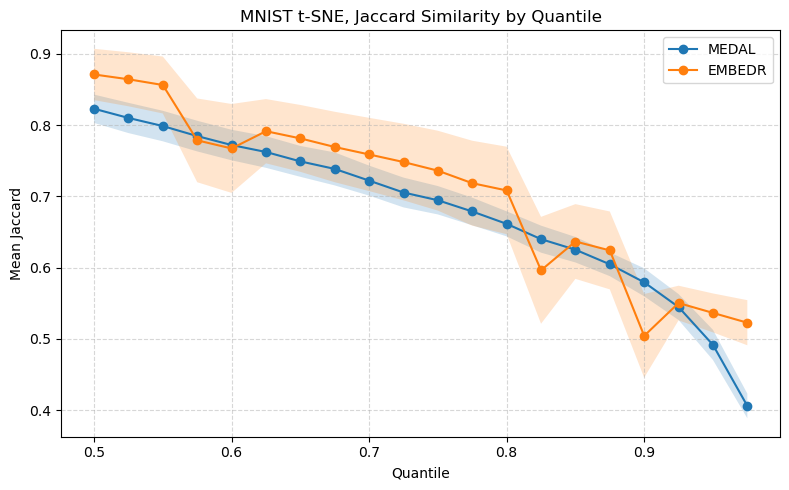

In [45]:
quantiles = np.linspace(0.5, 0.975, 20)

results = {
    "MEDAL": j3_medal_teachers,
    "EMBEDR": j3_embedr_teachers,
    # "PCS": j3_pcs_teachers,
}

fig, ax = plt.subplots(figsize=(8, 5))

for label, data in results.items():
    arr = np.stack(data)          # shape: (8, 10)
    means = arr.mean(axis=0)      # (10,)
    se = arr.std(axis=0) / np.sqrt(arr.shape[0])  # (10,)

    ax.plot(quantiles, means, marker='o', label=label)
    ax.fill_between(quantiles, means - se, means + se, alpha=0.2)

# ax.axhline(y=np.mean(j3_scdeed_teachers), color='red', label='SCDEED')
ax.set_xlabel("Quantile")
ax.set_ylabel("Mean Jaccard")
ax.set_title("MNIST t-SNE, Jaccard Similarity by Quantile")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [18]:
umap_param_sweep = np.unique(np.logspace(np.log10(5), np.log10(500), 15).astype(int))
per_sample_recon_medal_all_umap = {n: {} for n in umap_param_sweep}
per_sample_recon_scdeed_all_umap = {n: {} for n in umap_param_sweep}
per_sample_recon_embedr_all_umap = {n: {} for n in umap_param_sweep}
for s in [0,2, 10]:
    scdeed_df = pd.read_csv(Path(PATH_PREFIX) / f"MEDAL/comparisons/results_scdeed_umap/seed{s}/umap_best_mnist_train_full_results.csv", index_col=0)
    embedr_df = pd.read_csv(Path(PATH_PREFIX) / f'MEDAL/comparisons/results_embedr_umap_seed{s}/mnist_train/scores_per_point_all_n_neighbors.csv', index_col=0)
    for n in umap_param_sweep:
        teacher_embed = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/mnist_umap_{n}_0.1_{s}_train.npy")
        student = load_trained_ae(Path(PATH_PREFIX) / f"drd_data/tmp_results/chkpt_teacher_seed/mnist/medal_umap2_{n}_0.1_tc0_{s}_ckpts/final.pt",
                input_dim=784,
                hidden_dims=[512, 512, 512, 512],
                latent_dim=2, activation=torch.nn.SELU, batchnorm=False)
        
        student_recon, student_embed = student(torch.tensor(X, dtype=torch.float32))
        train_distill = np.mean((teacher_embed - student_embed.detach().numpy()) ** 2)
        if train_distill < 1e-5:
            per_sample_recon = np.mean((student_recon.detach().numpy() - X)**2, axis=1)
            per_sample_recon_medal_all_umap[n][s] = per_sample_recon
        
        per_sample_scdeed = split_scdeed_labels(scdeed_df, n)['label']
        per_sample_recon_scdeed_all_umap[n][s] = per_sample_scdeed == "dubious"
        per_sample_embedr = embedr_df.loc[n, 'embedr_pval']
        per_sample_recon_embedr_all_umap[n][s] = per_sample_embedr
    

/tmp/ipykernel_8553/3795533998.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0


/tmp/ipykernel_8553/3795533998.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0


/tmp/ipykernel_8553/3795533998.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0


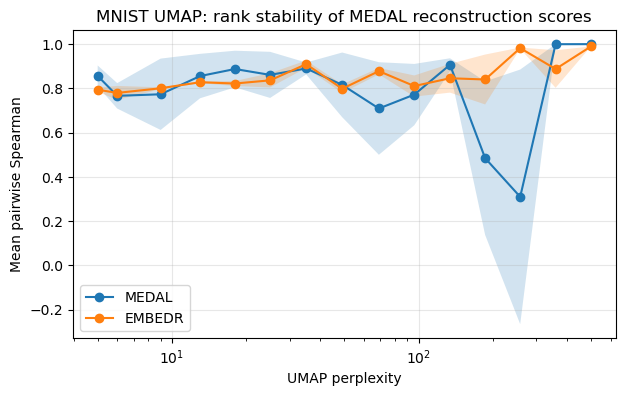

In [20]:
medal_pairwise_spearman_df, medal_mean_spearman_by_perp = summarize_rank_correlation(
    per_sample_recon_medal_all_umap
)
embedr_pairwise_spearman_df, embedr_mean_spearman_by_perp = summarize_rank_correlation(
    per_sample_recon_embedr_all_umap
)

plt.figure(figsize=(7, 4))
plt.plot(
    medal_mean_spearman_by_perp["hyperparam"],
    medal_mean_spearman_by_perp["mean_pairwise_spearman"],
    marker="o", label = 'MEDAL'
)
plt.plot(
    embedr_mean_spearman_by_perp["hyperparam"],
    embedr_mean_spearman_by_perp["mean_pairwise_spearman"],
    marker="o", label = 'EMBEDR'
)

plt.fill_between(
    medal_mean_spearman_by_perp["hyperparam"],
    medal_mean_spearman_by_perp["mean_pairwise_spearman"] - medal_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    medal_mean_spearman_by_perp["mean_pairwise_spearman"] + medal_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    alpha=0.2
)
plt.fill_between(
    embedr_mean_spearman_by_perp["hyperparam"],
    embedr_mean_spearman_by_perp["mean_pairwise_spearman"] - embedr_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    embedr_mean_spearman_by_perp["mean_pairwise_spearman"] + embedr_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    alpha=0.2
)
plt.xscale("log")
plt.legend()
plt.xlabel("UMAP perplexity")
plt.ylabel("Mean pairwise Spearman")
plt.title("MNIST UMAP: rank stability of MEDAL reconstruction scores")
plt.grid(True, alpha=0.3)
plt.show()

In [120]:
j3_medal_teachers, core_medal_teachers = zip(*[
    jaccard_curve(per_sample_recon_medal_all_umap[perp], np.linspace(0.8, 0.975, 20))
    for perp in umap_param_sweep
])
j3_medal_teachers = np.array(j3_medal_teachers)
core_medal_teachers = np.array(core_medal_teachers)

j3_embedr_teachers, core_embedr_teachers = zip(*[
    jaccard_curve(per_sample_recon_embedr_all_umap[perp], np.linspace(0.8, 0.975, 20))
    for perp in umap_param_sweep
])
j3_embedr_teachers = np.array(j3_embedr_teachers)
core_embedr_teachers = np.array(core_embedr_teachers)

j3_scdeed_teachers = [np.logical_and.reduce(per_sample_recon_scdeed_all_umap[n]).sum()/np.logical_or.reduce(per_sample_recon_scdeed_all_umap[n]).sum()
                     for n in umap_param_sweep]
quantiles = np.linspace(0.5, 0.975, 20)


q=0.800, inter=768, union=1904, mean_set_size=1280.0
q=0.809, inter=718, union=1838, mean_set_size=1221.0
q=0.818, inter=682, union=1756, mean_set_size=1162.0
q=0.828, inter=637, union=1686, mean_set_size=1103.0
q=0.837, inter=597, union=1611, mean_set_size=1045.0
q=0.846, inter=558, union=1529, mean_set_size=986.0
q=0.855, inter=518, union=1456, mean_set_size=927.0
q=0.864, inter=477, union=1366, mean_set_size=868.0
q=0.874, inter=440, union=1284, mean_set_size=809.0
q=0.883, inter=403, union=1191, mean_set_size=750.0
q=0.892, inter=365, union=1103, mean_set_size=691.0
q=0.901, inter=339, union=1017, mean_set_size=632.0
q=0.911, inter=296, union=943, mean_set_size=573.0
q=0.920, inter=261, union=840, mean_set_size=514.0
q=0.929, inter=223, union=754, mean_set_size=455.0
q=0.938, inter=188, union=664, mean_set_size=396.0
q=0.947, inter=148, union=589, mean_set_size=337.0
q=0.957, inter=113, union=486, mean_set_size=278.0
q=0.966, inter=82, union=386, mean_set_size=219.0
q=0.975, inter=

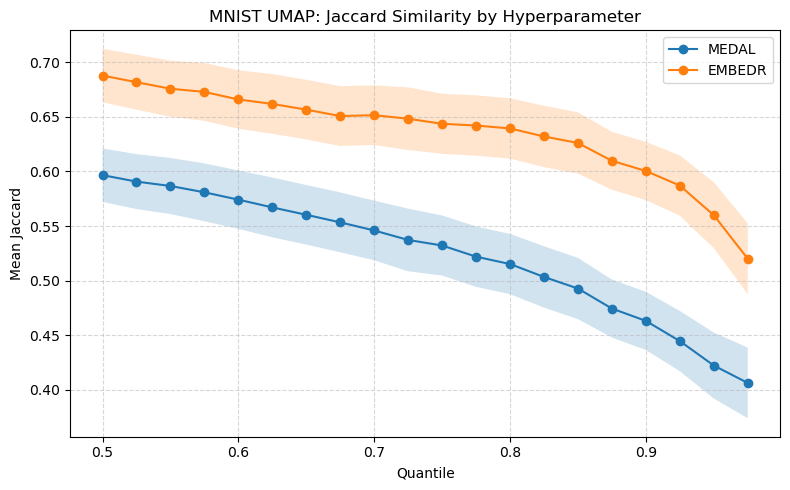

In [123]:
results = {
    "MEDAL": core_medal_teachers,
    "EMBEDR": core_embedr_teachers,
}
fig, ax = plt.subplots(figsize=(8, 5))

for label, data in results.items():        
    means = data.mean(axis=0)      
    se = arr.std(axis=0) / np.sqrt(arr.shape[0])  

    ax.plot(quantiles, means, marker='o', label=label)
    ax.fill_between(quantiles, means - se, means + se, alpha=0.2)

# ax.plot(quantiles, j3_scdeed_teachers, color='violet', label='SCDEED', marker='o',)
ax.set_xlabel("Quantile")
ax.set_ylabel("Mean Jaccard")
ax.set_title("MNIST UMAP: Jaccard Similarity by Hyperparameter")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Hydra

In [9]:
X_og, X_test, y_og, y_test = load_and_split("hydra", test_size=0.2, seed=0, labels=True)
X, X_val, y, y_val = train_test_split(X_og, y_og, test_size=0.2, random_state=0)

hydra_palette = color_map = {
    "enEp_tentacle": "#1e3a8a",
    "enEp_stem_cell": "#1d4ed8",
    "enEp_foot": "#2563eb",
    "enEp_head": "#3b82f6",
    "enEp-nb(pd)": "#60a5fa",
    "enEp-nem(pd)": "#93c5fd",
    "enEp_tent-nem(pd)": "#bfdbfe",
    "ecEp-nb(pd)": "#134e4a",
    "ecEp_battery_cell2(mp)": "#0f766e",
    "ecEp_stem_cell": "#0d9488",
    "ecEp_head": "#14b8a6",
    "ecEp-nem(id)": "#2dd4bf",
    "ecEp_basal_disk": "#5eead4",
    "ecEp_battery_cell1(mp)": "#99f6e4",
    "i_stem_cell/progenitor": "#4a044e",
    "i_neuron/gland_cell_progenitor": "#6b21a8",
    "i_neuron_progenitor": "#7e22ce",
    "i_nb1": "#7c2d12",
    "i_nb2": "#c2410c",
    "i_nb3": "#ea580c",
    "i_nb4": "#f97316",
    "i_nb5": "#fb923c",
    "i_neuron_ec1": "#831843",
    "i_neuron_ec2": "#be185d",
    "i_neuron_ec3": "#db2777",
    "i_neuron_ec4": "#ec4899",
    "i_neuron_ec5": "#f472b6",
    "i_neuron_en1": "#3b0764",
    "i_neuron_en2": "#5b21b6",
    "i_neuron_en3": "#7c3aed",
    "i_female_germline1": "#312e81",
    "i_female_germline2_nurse": "#4338ca",
    "i_male_germline": "#818cf8",
    "i_granular_mucous_gland_cell": "#7f1d1d",
    "i_zymogen_gland_cell": "#b91c1c",
    "i_spumous_mucous_gland_cell": "#ef4444",
    "i_nematocyte": "#92400e",
    "db": "#d97706",
}

category_map = {
    "enEp_tentacle": "enEp",
    "enEp_stem_cell": "enEp",
    "enEp_foot": "enEp",
    "enEp_head": "enEp",
    "enEp-nb(pd)": "enEp",
    "enEp-nem(pd)": "enEp",
    "enEp_tent-nem(pd)": "enEp",
    "ecEp-nb(pd)": "ecEp",
    "ecEp_battery_cell2(mp)": "ecEp",
    "ecEp_stem_cell": "ecEp",
    "ecEp_head": "ecEp",
    "ecEp-nem(id)": "ecEp",
    "ecEp_basal_disk": "ecEp",
    "ecEp_battery_cell1(mp)": "ecEp",
    "i_stem_cell/progenitor": "i_progenitors",
    "i_neuron/gland_cell_progenitor": "i_progenitors",
    "i_neuron_progenitor": "i_progenitors",
    "i_nb1": "i_neuroblasts",
    "i_nb2": "i_neuroblasts",
    "i_nb3": "i_neuroblasts",
    "i_nb4": "i_neuroblasts",
    "i_nb5": "i_neuroblasts",
    "i_neuron_ec1": "i_neurons_ec",
    "i_neuron_ec2": "i_neurons_ec",
    "i_neuron_ec3": "i_neurons_ec",
    "i_neuron_ec4": "i_neurons_ec",
    "i_neuron_ec5": "i_neurons_ec",
    "i_neuron_en1": "i_neurons_en",
    "i_neuron_en2": "i_neurons_en",
    "i_neuron_en3": "i_neurons_en",
    "i_female_germline1": "i_germline",
    "i_female_germline2_nurse": "i_germline",
    "i_male_germline": "i_germline",
    "i_granular_mucous_gland_cell": "i_gland",
    "i_zymogen_gland_cell": "i_gland",
    "i_spumous_mucous_gland_cell": "i_gland",
    "i_nematocyte": "i_nematocyte",
    "db": "db",
}
y_og_big_categories = pd.Series(y_og).map(category_map).values
y_big_categories = pd.Series(y).map(category_map).values

In [20]:
tsne_param_sweep = np.unique(np.logspace(np.log10(5), np.log10(5000), 10).astype(int))
per_sample_recon_medal_all_tsne = {perp: {} for perp in tsne_param_sweep}
per_sample_recon_scdeed_all_tsne = {perp: {} for perp in tsne_param_sweep}
per_sample_recon_embedr_all_tsne = {perp: {} for perp in tsne_param_sweep}
per_sample_recon_pcs_all_tsne = {perp: {} for perp in tsne_param_sweep}
for s in [0, 2, 10]:
    pcs_df = pd.read_csv(Path(PATH_PREFIX) / f'MEDAL/comparisons/results_pcs_seed{s}/hydra_train/scores_per_point_all_perplexities.csv', index_col=0)
    embedr_df = pd.read_csv(Path(PATH_PREFIX) / f'MEDAL/comparisons/results_embedr_tsne_seed{s}/hydra_train/scores_per_point_all_perplexities.csv', index_col=0)
    for perp in tsne_param_sweep:
        teacher_embed = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/hydra_tsne_{perp}_{s}_train.npy")
        student = load_trained_ae(Path(PATH_PREFIX) / f"drd_data/tmp_results/chkpt_teacher_seed/hydra/medal_tsne2_{perp}_tc0_{s}_ckpts/final.pt",
                    input_dim=500,
                    hidden_dims=[309, 1792, 1792, 1792],
                    latent_dim=2, batchnorm=True)
        
        student_recon, student_embed = student(torch.tensor(X, dtype=torch.float32))
        train_distill = np.mean((teacher_embed - student_embed.detach().numpy()) ** 2)
        if train_distill < 1e-5:
            per_sample_recon = np.mean((student_recon.detach().numpy() - X)**2, axis=1)
            per_sample_recon_medal_all_tsne[perp][s] = per_sample_recon
        
        # per_sample_scdeed = split_scdeed_labels(scdeed_df, perp)['label']
        # per_sample_recon_scdeed_all_tsne[perp].append(per_sample_scdeed == "dubious")
        per_sample_embedr = embedr_df.loc[perp, 'embedr_pval']
        per_sample_recon_embedr_all_tsne[perp][s] = per_sample_embedr
        per_sample_pcs = pcs_df.loc[perp, 'sscore']
        per_sample_recon_pcs_all_tsne[perp][s] = per_sample_pcs
for s in [2,3,10]:
    scdeed_df = pd.read_csv(Path(PATH_PREFIX) / f"MEDAL/comparisons/results_scdeed_tsne/seed{s}/tsne_best_mnist_train_full_results.csv", index_col=0)
    for perp in tsne_param_sweep:
        per_sample_scdeed = split_scdeed_labels(scdeed_df, perp)['label']
        per_sample_recon_scdeed_all_tsne[perp][s] = per_sample_scdeed == "dubious"
    

/tmp/ipykernel_24534/3795533998.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0


/tmp/ipykernel_24534/3795533998.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0


/tmp/ipykernel_24534/3795533998.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0


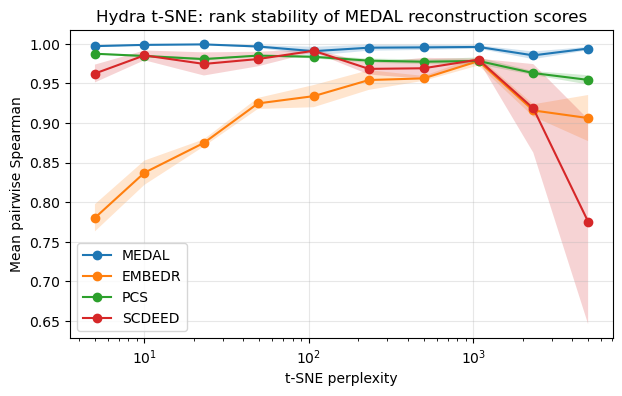

In [26]:
medal_pairwise_spearman_df, medal_mean_spearman_by_perp = summarize_rank_correlation(
    per_sample_recon_medal_all_tsne
)
embedr_pairwise_spearman_df, embedr_mean_spearman_by_perp = summarize_rank_correlation(
    per_sample_recon_embedr_all_tsne
)

pcs_pairwise_spearman_df, pcs_mean_spearman_by_perp = summarize_rank_correlation(
    per_sample_recon_pcs_all_tsne
)
scdeed_pairwise_spearman_df, scdeed_mean_spearman_by_perp = summarize_rank_correlation(
    per_sample_recon_scdeed_all_tsne
)

plt.figure(figsize=(7, 4))
plt.plot(
    medal_mean_spearman_by_perp["hyperparam"],
    medal_mean_spearman_by_perp["mean_pairwise_spearman"],
    marker="o", label = 'MEDAL'
)
plt.plot(
    embedr_mean_spearman_by_perp["hyperparam"],
    embedr_mean_spearman_by_perp["mean_pairwise_spearman"],
    marker="o", label = 'EMBEDR'
)
plt.plot(
    pcs_mean_spearman_by_perp["hyperparam"],
    pcs_mean_spearman_by_perp["mean_pairwise_spearman"],
    marker="o", label = 'PCS'
)
plt.plot(
    scdeed_mean_spearman_by_perp["hyperparam"],
    scdeed_mean_spearman_by_perp["mean_pairwise_spearman"],
    marker="o", label = 'SCDEED'
)

plt.fill_between(
    medal_mean_spearman_by_perp["hyperparam"],
    medal_mean_spearman_by_perp["mean_pairwise_spearman"] - medal_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    medal_mean_spearman_by_perp["mean_pairwise_spearman"] + medal_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    alpha=0.2
)
plt.fill_between(
    embedr_mean_spearman_by_perp["hyperparam"],
    embedr_mean_spearman_by_perp["mean_pairwise_spearman"] - embedr_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    embedr_mean_spearman_by_perp["mean_pairwise_spearman"] + embedr_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    alpha=0.2
)
plt.fill_between(
    pcs_mean_spearman_by_perp["hyperparam"],
    pcs_mean_spearman_by_perp["mean_pairwise_spearman"] - pcs_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    pcs_mean_spearman_by_perp["mean_pairwise_spearman"] + pcs_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    alpha=0.2
)
plt.fill_between(
    scdeed_mean_spearman_by_perp["hyperparam"],
    scdeed_mean_spearman_by_perp["mean_pairwise_spearman"] - scdeed_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    scdeed_mean_spearman_by_perp["mean_pairwise_spearman"] + scdeed_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    alpha=0.2
)
plt.xscale("log")
plt.legend()
plt.xlabel("t-SNE perplexity")
plt.ylabel("Mean pairwise Spearman")
plt.title("Hydra t-SNE: rank stability of MEDAL reconstruction scores")
plt.grid(True, alpha=0.3)
plt.show()

In [50]:
j3_medal_teachers  = [jaccard_curve(per_sample_recon_medal_all_tsne[perp], np.linspace(0.8, 0.975, 20)) 
                     for perp in tsne_param_sweep]
j3_embedr_teachers = [jaccard_curve(per_sample_recon_embedr_all_tsne[perp], np.linspace(0.8, 0.975, 20)) 
                     for perp in tsne_param_sweep]
j3_pcs_teachers = [jaccard_curve(per_sample_recon_pcs_all_tsne[perp], np.linspace(0.8, 0.975, 20)) 
                     for perp in tsne_param_sweep]
# j3_scdeed_teachers = [np.logical_and.reduce(per_sample_recon_scdeed_all_tsne[perp]).sum()/np.logical_or.reduce(per_sample_recon_scdeed_all_tsne[perp]).sum()
#                      for perp in tsne_param_sweep]

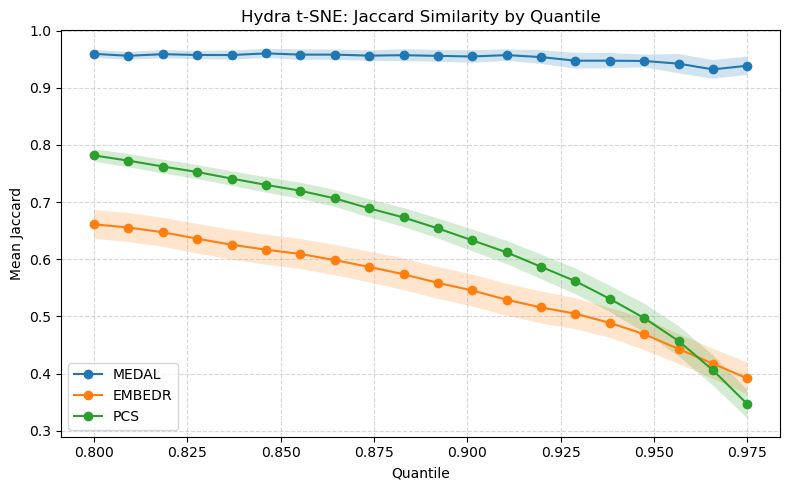

In [51]:
quantiles = np.linspace(0.8, 0.975, 20)

results = {
    "MEDAL": j3_medal_teachers,
    "EMBEDR": j3_embedr_teachers,
    "PCS": j3_pcs_teachers,
}

fig, ax = plt.subplots(figsize=(8, 5))

for label, data in results.items():
    arr = np.stack(data)          # shape: (8, 10)
    means = arr.mean(axis=0)      # (10,)
    se = arr.std(axis=0) / np.sqrt(arr.shape[0])  # (10,)

    ax.plot(quantiles, means, marker='o', label=label)
    ax.fill_between(quantiles, means - se, means + se, alpha=0.2)

ax.set_xlabel("Quantile")
ax.set_ylabel("Mean Jaccard")
ax.set_title("Hydra t-SNE: Jaccard Similarity by Quantile")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

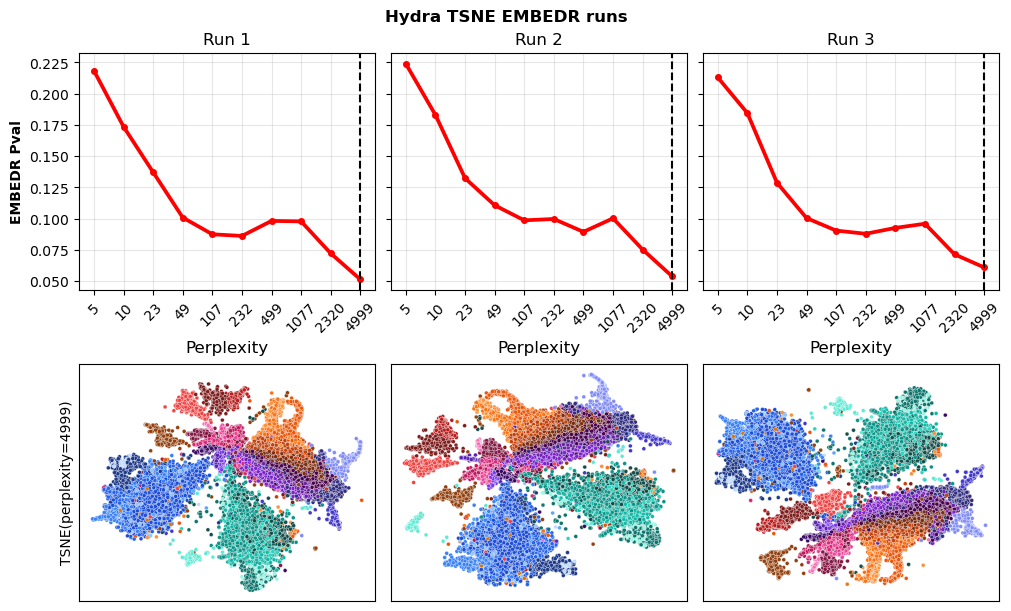

In [200]:
embedr_1_best, embedr_2_best, embedr_3_best = 4999, 4999, 4999
teacher_embed = {}
embedr_df1 = pd.read_csv(Path(PATH_PREFIX) / 'MEDAL/comparisons/results_embedr_tsne_seed0/hydra_train/X_with_best_scores.csv')
per_sample_embedr1 = embedr_df1[f'embedr_pval_meanbest_{embedr_1_best}']
embedr_df2 = pd.read_csv(Path(PATH_PREFIX) / 'MEDAL/comparisons/results_embedr_tsne_seed10/hydra_train/X_with_best_scores.csv')
per_sample_embedr2 = embedr_df2[f'embedr_pval_meanbest_{embedr_2_best}']
embedr_df3 = pd.read_csv(Path(PATH_PREFIX) / 'MEDAL/comparisons/results_embedr_tsne_seed2/hydra_train/X_with_best_scores.csv')
per_sample_embedr3 = embedr_df3[f'embedr_pval_meanbest_{embedr_3_best}']

embedr_analysis1 = pd.read_csv(Path(PATH_PREFIX) / 'MEDAL/comparisons/results_embedr_tsne_seed0/hydra_train/elbow_df.csv',  index_col = 0)
embedr_tsne_argmin = embedr_analysis1.groupby('perplexity')['mean_embedr_pval'].mean().idxmin()
argmin_position1 = embedr_analysis1.index.tolist().index(embedr_tsne_argmin)
embedr_analysis2 = pd.read_csv(Path(PATH_PREFIX) / 'MEDAL/comparisons/results_embedr_tsne_seed10/hydra_train/elbow_df.csv', index_col = 0)
embedr_tsne_argmin = embedr_analysis2.groupby('perplexity')['mean_embedr_pval'].mean().idxmin()
argmin_position2 = embedr_analysis2.index.tolist().index(embedr_tsne_argmin)
embedr_analysis3 = pd.read_csv(Path(PATH_PREFIX) / 'MEDAL/comparisons/results_embedr_tsne_seed2/hydra_train/elbow_df.csv', index_col = 0)
embedr_tsne_argmin = embedr_analysis3.groupby('perplexity')['mean_embedr_pval'].mean().idxmin()
argmin_position3 = embedr_analysis3.index.tolist().index(embedr_tsne_argmin)

fig, axes = plt.subplots(2,3, figsize=(10, 6), constrained_layout=True, sharey = 'row')
axes_flat = axes.flatten()

# 1st row 
sns.pointplot(data=embedr_analysis1, x='perplexity', y='mean_embedr_pval', color='red', markersize=3, ax = axes_flat[0])
axes_flat[0].axvline(x = argmin_position1, ls = '--', c ='black')
axes_flat[0].set_title("Run 1")
axes_flat[0].set_ylabel("EMBEDR Pval", fontweight='bold')

sns.pointplot(data=embedr_analysis2, x='perplexity', y='mean_embedr_pval', color='red', markersize=3, ax = axes_flat[1])
axes_flat[1].axvline(x = argmin_position2, ls = '--', c ='black') 
axes_flat[1].set_title("Run 2")

sns.pointplot(data=embedr_analysis3, x='perplexity', y='mean_embedr_pval', color='red', markersize=3, ax = axes_flat[2])
axes_flat[2].axvline(x = argmin_position3, ls = '--', c ='black') 
axes_flat[2].set_title("Run 3")

# 2nd row 
teacher_embed['embedr_1'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/hydra_tsne_{embedr_1_best}_0_train_embedr.npy").squeeze(0)
teacher_embed['embedr_2'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/hydra_tsne_{embedr_1_best}_10_train_embedr.npy").squeeze(0)
teacher_embed['embedr_3'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/hydra_tsne_{embedr_1_best}_2_train_embedr.npy")[0,:]
sns.scatterplot(x=teacher_embed['embedr_1'][:, 0], y=teacher_embed['embedr_1'][:, 1], 
                ax=axes_flat[3], s=8, hue=y_og, palette = hydra_palette,
                # palette=cmap, 
                # hue_norm=plt.Normalize(vmin=np.quantile(per_sample_embedr1, 0.025), vmax=np.quantile(per_sample_embedr1, 0.975)), 
                legend=False, rasterized=True)
sns.scatterplot(x=teacher_embed['embedr_2'][:, 0], y=teacher_embed['embedr_2'][:, 1], 
                ax=axes_flat[4], s=8, hue=y_og, palette = hydra_palette,
                # palette=cmap, 
                # hue_norm=plt.Normalize(vmin=np.quantile(per_sample_embedr2, 0.025), vmax=np.quantile(per_sample_embedr2, 0.975)), 
                legend=False, rasterized=True)
sns.scatterplot(x=teacher_embed['embedr_3'][:, 0], y=teacher_embed['embedr_3'][:, 1], 
                ax=axes_flat[5], s=8, hue=y_og, palette = hydra_palette,
                # palette=cmap, 
                # hue_norm=plt.Normalize(vmin=np.quantile(per_sample_embedr3, 0.025), vmax=np.quantile(per_sample_embedr3, 0.975)), 
                legend=False, rasterized=True)

axes_flat[3].set_ylabel(f"TSNE(perplexity={embedr_1_best})")
for i in [0,1,2]:
    axes_flat[i].grid(True, alpha=0.3)
    axes_flat[i].set_xlabel("Perplexity", fontsize=12)
    plt.setp(axes_flat[i].get_xticklabels(), rotation=45, ha='center')
for i in [3,4,5]:
    axes_flat[i].set_xticks([])
    axes_flat[i].set_yticks([])
fig.suptitle("Hydra TSNE EMBEDR runs", fontweight='bold')
plt.show()

## Tasic

In [74]:
X_og, X_test, y_og, y_test = load_and_split("tasic", test_size=0.2, seed=0, labels=True)
X, X_val, y, y_val = train_test_split(X_og, y_og, test_size=0.2, random_state=0)
labels = np.load(Path(PATH_PREFIX) / 'drd_data/tasic_cluster_labels.npy', allow_pickle=True)
colors = np.load(Path(PATH_PREFIX) / 'drd_data/tasic_cluster_colors.npy', allow_pickle=True)
categories = np.unique(labels)
tasic_palette = {cat: col for cat, col in zip(categories, colors)}

class_labels = np.load(Path(PATH_PREFIX) / 'drd_data/tasic_class_labels.npy', allow_pickle=True)
y_class_og, y_class_test = train_test_split(class_labels, test_size=0.2, random_state=0)
y_class, y_class_val = train_test_split(y_class_og, test_size=0.2, random_state=0)
class_colors = np.load(Path(PATH_PREFIX) / 'drd_data/tasic_class_colors.npy', allow_pickle=True)
tasic_palette_class = {"Glutamatergic": "#e5b68b", "GABAergic": "#307c47", "Non-Neuronal": "#2C94EF", "Endothelial": "#32D7FC"}

In [75]:
tsne_param_sweep = np.unique(np.logspace(np.log10(5), np.log10(6000), 10).astype(int))
per_sample_recon_medal_all_tsne = {perp: {} for perp in tsne_param_sweep}
per_sample_recon_scdeed_all_tsne = {perp: {} for perp in tsne_param_sweep}
per_sample_recon_embedr_all_tsne = {perp: {} for perp in tsne_param_sweep}
per_sample_recon_pcs_all_tsne = {perp: {} for perp in tsne_param_sweep}
for s in [0, 2, 10]:
    pcs_df = pd.read_csv(Path(PATH_PREFIX) / f'MEDAL/comparisons/results_pcs_seed{s}/tasic_train/scores_per_point_all_perplexities.csv', index_col=0)
    # scdeed_df = pd.read_csv(Path(PATH_PREFIX) / f"MEDAL/comparisons/results_scdeed_tsne/seed{s}/tsne_best_mnist_train_full_results.csv", index_col=0)
    embedr_df = pd.read_csv(Path(PATH_PREFIX) / f'MEDAL/comparisons/results_embedr_tsne_seed{s}/tasic_train/scores_per_point_all_perplexities.csv', index_col=0)
    for perp in tsne_param_sweep:
        teacher_embed = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/tasic_tsne_{perp}_{s}_train.npy")
        student = load_trained_ae(Path(PATH_PREFIX) / f"drd_data/tmp_results/chkpt_teacher_seed/tasic/medal_tsne2_{perp}_tc0_{s}_ckpts/final.pt",
                    input_dim=1000,
                    hidden_dims=[309, 1792, 1792, 1792],
                    latent_dim=2, batchnorm=True)
        
        student_recon, student_embed = student(torch.tensor(X, dtype=torch.float32))
        train_distill = np.mean((teacher_embed - student_embed.detach().numpy()) ** 2)
        if train_distill < 1e-5:
            per_sample_recon = np.mean((student_recon.detach().numpy() - X)**2, axis=1)
            per_sample_recon_medal_all_tsne[perp][s] = per_sample_recon
        
        # per_sample_scdeed = split_scdeed_labels(scdeed_df, perp)['label']
        # per_sample_recon_scdeed_all_tsne[perp].append(per_sample_scdeed == "dubious")
        per_sample_embedr = embedr_df.loc[perp, 'embedr_pval']
        per_sample_recon_embedr_all_tsne[perp][s] = per_sample_embedr
        per_sample_pcs = pcs_df.loc[perp, 'sscore']
        per_sample_recon_pcs_all_tsne[perp][s] = per_sample_pcs
    

/tmp/ipykernel_24534/3795533998.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0


/tmp/ipykernel_24534/3795533998.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0


/tmp/ipykernel_24534/3795533998.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0


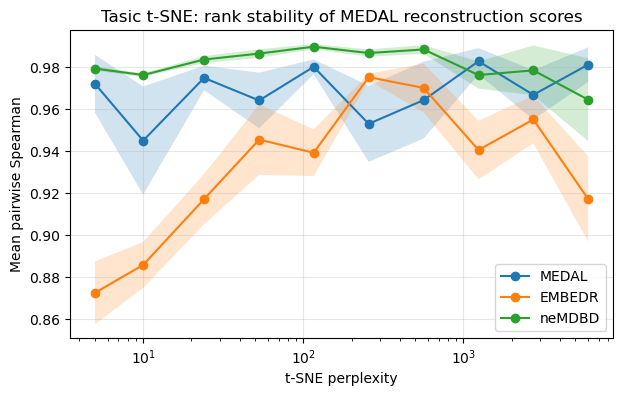

In [82]:
medal_pairwise_spearman_df, medal_mean_spearman_by_perp = summarize_rank_correlation(
    per_sample_recon_medal_all_tsne
)
embedr_pairwise_spearman_df, embedr_mean_spearman_by_perp = summarize_rank_correlation(
    per_sample_recon_embedr_all_tsne
)
pcs_pairwise_spearman_df, pcs_mean_spearman_by_perp = summarize_rank_correlation(
    per_sample_recon_pcs_all_tsne
)

plt.figure(figsize=(7, 4))
plt.plot(
    medal_mean_spearman_by_perp["hyperparam"],
    medal_mean_spearman_by_perp["mean_pairwise_spearman"],
    marker="o", label = 'MEDAL'
)
plt.plot(
    embedr_mean_spearman_by_perp["hyperparam"],
    embedr_mean_spearman_by_perp["mean_pairwise_spearman"],
    marker="o", label = 'EMBEDR'
)
plt.plot(
    pcs_mean_spearman_by_perp["hyperparam"],
    pcs_mean_spearman_by_perp["mean_pairwise_spearman"],
    marker="o", label = 'neMDBD'
)

plt.fill_between(
    medal_mean_spearman_by_perp["hyperparam"],
    medal_mean_spearman_by_perp["mean_pairwise_spearman"] - medal_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    medal_mean_spearman_by_perp["mean_pairwise_spearman"] + medal_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    alpha=0.2
)
plt.fill_between(
    embedr_mean_spearman_by_perp["hyperparam"],
    embedr_mean_spearman_by_perp["mean_pairwise_spearman"] - embedr_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    embedr_mean_spearman_by_perp["mean_pairwise_spearman"] + embedr_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    alpha=0.2
)
plt.fill_between(
    pcs_mean_spearman_by_perp["hyperparam"],
    pcs_mean_spearman_by_perp["mean_pairwise_spearman"] - pcs_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    pcs_mean_spearman_by_perp["mean_pairwise_spearman"] + pcs_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    alpha=0.2
)
plt.xscale("log")
plt.legend()
plt.xlabel("t-SNE perplexity")
plt.ylabel("Mean pairwise Spearman")
plt.title("Tasic t-SNE: rank stability of MEDAL reconstruction scores")
plt.grid(True, alpha=0.3)
plt.show()

In [83]:
j3_medal_teachers, core_medal_teachers = zip(*[
    jaccard_curve(per_sample_recon_medal_all_tsne[perp], np.linspace(0.925, 0.99, 20))
    for perp in tsne_param_sweep
])
j3_medal_teachers = np.array(j3_medal_teachers)
core_medal_teachers = np.array(core_medal_teachers)

j3_embedr_teachers, core_embedr_teachers = zip(*[
    jaccard_curve(per_sample_recon_embedr_all_tsne[perp], np.linspace(0.925, 0.99, 20))
    for perp in tsne_param_sweep
])
j3_embedr_teachers = np.array(j3_embedr_teachers)
core_embedr_teachers = np.array(core_embedr_teachers)

j3_pcs_teachers, core_pcs_teachers = zip(*[
    jaccard_curve(per_sample_recon_pcs_all_tsne[perp], np.linspace(0.925, 0.99, 20))
    for perp in tsne_param_sweep
])
j3_pcs_teachers = np.array(j3_pcs_teachers)
core_pcs_teachers = np.array(core_pcs_teachers)

# j3_scdeed_teachers = [np.logical_and.reduce(per_sample_recon_scdeed_all_tsne[perp]).sum()/np.logical_or.reduce(per_sample_recon_scdeed_all_tsne[perp]).sum()
#                      for perp in tsne_param_sweep]

q=0.925, inter=1120, union=1174, mean_set_size=1144.0
q=0.928, inter=1074, union=1109, mean_set_size=1092.0
q=0.932, inter=1026, union=1055, mean_set_size=1039.0
q=0.935, inter=976, union=996, mean_set_size=987.0
q=0.939, inter=930, union=940, mean_set_size=935.0
q=0.942, inter=879, union=887, mean_set_size=883.0
q=0.946, inter=807, union=849, mean_set_size=831.0
q=0.949, inter=722, union=824, mean_set_size=779.0
q=0.952, inter=652, union=791, mean_set_size=727.0
q=0.956, inter=576, union=761, mean_set_size=674.0
q=0.959, inter=519, union=721, mean_set_size=622.0
q=0.963, inter=457, union=676, mean_set_size=570.0
q=0.966, inter=419, union=622, mean_set_size=518.0
q=0.969, inter=384, union=549, mean_set_size=466.0
q=0.973, inter=359, union=483, mean_set_size=414.0
q=0.976, inter=327, union=403, mean_set_size=362.0
q=0.980, inter=262, union=348, mean_set_size=309.0
q=0.983, inter=209, union=303, mean_set_size=257.0
q=0.987, inter=137, union=267, mean_set_size=205.0
q=0.990, inter=84, uni

q=0.987, inter=154, union=264, mean_set_size=205.0
q=0.990, inter=118, union=197, mean_set_size=153.0
q=0.925, inter=789, union=2163, mean_set_size=1430.0
q=0.928, inter=754, union=2076, mean_set_size=1365.3
q=0.932, inter=714, union=1989, mean_set_size=1299.3
q=0.935, inter=677, union=1890, mean_set_size=1234.0
q=0.939, inter=634, union=1805, mean_set_size=1169.0
q=0.942, inter=589, union=1711, mean_set_size=1104.3
q=0.946, inter=549, union=1623, mean_set_size=1039.7
q=0.949, inter=523, union=1525, mean_set_size=973.3
q=0.952, inter=476, union=1437, mean_set_size=908.3
q=0.956, inter=438, union=1339, mean_set_size=843.3
q=0.959, inter=394, union=1255, mean_set_size=778.3
q=0.963, inter=357, union=1157, mean_set_size=713.7
q=0.966, inter=312, union=1068, mean_set_size=647.0
q=0.969, inter=281, union=967, mean_set_size=582.0
q=0.973, inter=251, union=863, mean_set_size=517.0
q=0.976, inter=221, union=755, mean_set_size=452.7
q=0.980, inter=174, union=653, mean_set_size=387.0
q=0.983, in

q=0.928, inter=931, union=1824, mean_set_size=1365.0
q=0.932, inter=879, union=1761, mean_set_size=1299.0
q=0.935, inter=824, union=1691, mean_set_size=1234.0
q=0.939, inter=768, union=1607, mean_set_size=1169.0
q=0.942, inter=726, union=1515, mean_set_size=1104.0
q=0.946, inter=677, union=1437, mean_set_size=1039.0
q=0.949, inter=623, union=1359, mean_set_size=973.0
q=0.952, inter=556, union=1281, mean_set_size=908.0
q=0.956, inter=498, union=1216, mean_set_size=843.0
q=0.959, inter=452, union=1138, mean_set_size=778.0
q=0.963, inter=395, union=1062, mean_set_size=713.0
q=0.966, inter=350, union=984, mean_set_size=647.0
q=0.969, inter=296, union=903, mean_set_size=582.0
q=0.973, inter=257, union=822, mean_set_size=517.0
q=0.976, inter=207, union=740, mean_set_size=452.0
q=0.980, inter=169, union=646, mean_set_size=387.0
q=0.983, inter=129, union=546, mean_set_size=321.0
q=0.987, inter=88, union=453, mean_set_size=256.0
q=0.990, inter=67, union=352, mean_set_size=191.0
q=0.925, inter=1

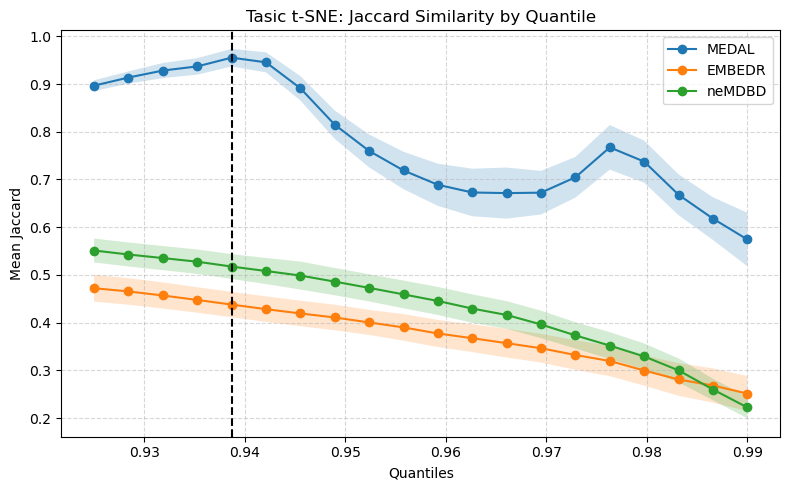

In [84]:
quantiles = np.linspace(0.925, 0.99, 20)

results = {
    "MEDAL": j3_medal_teachers,
    "EMBEDR": j3_embedr_teachers,
    "neMDBD": j3_pcs_teachers,
}

fig, ax = plt.subplots(figsize=(8, 5))

for label, data in results.items():
    print
    # arr = np.stack(data)          
    means = data.mean(axis=0)      
    se = data.std(axis=0) / np.sqrt(data.shape[0])  

    ax.plot(quantiles,means, marker='o', label=label)
    ax.fill_between(quantiles, means - se, means + se, alpha=0.2)

ax.axvline(x = quantiles[4], ls = '--', c ='black')
ax.set_xlabel("Quantiles")
ax.set_ylabel("Mean Jaccard")
ax.set_title("Tasic t-SNE: Jaccard Similarity by Quantile")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

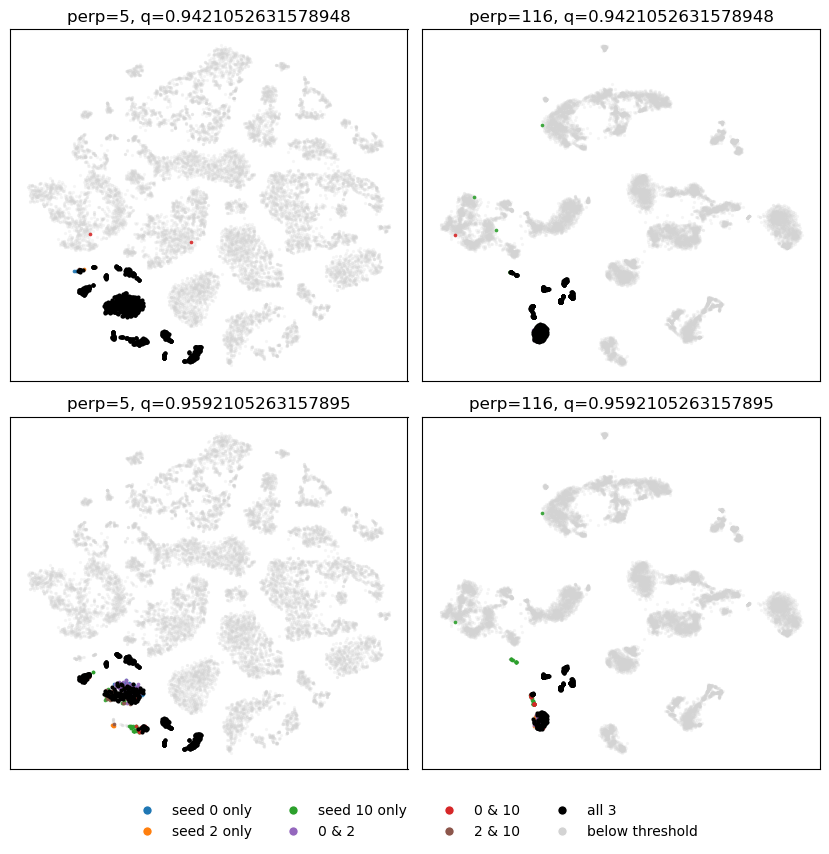

In [147]:
def plot_seed_overlap_grid(
    path_prefix,
    per_sample_recon_medal_all_tsne,
    perps=(5, 24, 116, 6000),
    quantiles=(0.875, 0.9),
    ref_seed=0,
    seed_labels=(0, 2, 10),
    figsize_per_panel=(4.2, 4.2),
    s_bg=5,
    s_fg=7,
    alpha_bg=0.22,
    alpha_fg=0.9,
):
    nrows = len(quantiles)
    ncols = len(perps)
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(figsize_per_panel[0] * ncols, figsize_per_panel[1] * nrows),
        squeeze=False
    )

    for i, q in enumerate(quantiles):
        for j, perp in enumerate(perps):
            ax = axes[i, j]

            embed_ref = np.load(
                Path(path_prefix) / f"drd_data/embeddings2/tasic_tsne_{perp}_{ref_seed}_train.npy"
            )
            scores_runs = [np.asarray(x) for x in per_sample_recon_medal_all_tsne[perp]]
            masks = [x >= np.quantile(x, q) for x in scores_runs]
            m0, m1, m2 = masks

            none   = ~(m0 | m1 | m2)
            only0  =  m0 & ~m1 & ~m2
            only1  = ~m0 &  m1 & ~m2
            only2  = ~m0 & ~m1 &  m2
            both01 =  m0 &  m1 & ~m2
            both02 =  m0 & ~m1 &  m2
            both12 = ~m0 &  m1 &  m2
            all3   =  m0 &  m1 &  m2

            ax.scatter(embed_ref[none, 0], embed_ref[none, 1],
                       c="lightgrey", s=s_bg, alpha=alpha_bg, linewidths=0)

            ax.scatter(embed_ref[only0, 0], embed_ref[only0, 1],
                       c="tab:blue", s=s_fg, alpha=alpha_fg, linewidths=0)
            ax.scatter(embed_ref[only1, 0], embed_ref[only1, 1],
                       c="tab:orange", s=s_fg, alpha=alpha_fg, linewidths=0)
            ax.scatter(embed_ref[only2, 0], embed_ref[only2, 1],
                       c="tab:green", s=s_fg, alpha=alpha_fg, linewidths=0)

            ax.scatter(embed_ref[both01, 0], embed_ref[both01, 1],
                       c="tab:purple", s=s_fg, alpha=alpha_fg, linewidths=0)
            ax.scatter(embed_ref[both02, 0], embed_ref[both02, 1],
                       c="tab:red", s=s_fg, alpha=alpha_fg, linewidths=0)
            ax.scatter(embed_ref[both12, 0], embed_ref[both12, 1],
                       c="tab:brown", s=s_fg, alpha=alpha_fg, linewidths=0)

            ax.scatter(embed_ref[all3, 0], embed_ref[all3, 1],
                       c="black", s=s_fg + 2, alpha=1.0, linewidths=0)

            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_title(f"perp={perp}, q={q}")

    # legend from dummy handles
    handles = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:blue',   markersize=7, label=f"seed {seed_labels[0]} only"),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:orange', markersize=7, label=f"seed {seed_labels[1]} only"),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:green',  markersize=7, label=f"seed {seed_labels[2]} only"),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:purple', markersize=7, label=f"{seed_labels[0]} & {seed_labels[1]}"),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:red',    markersize=7, label=f"{seed_labels[0]} & {seed_labels[2]}"),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:brown',  markersize=7, label=f"{seed_labels[1]} & {seed_labels[2]}"),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='black',      markersize=7, label="all 3"),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgrey',  markersize=7, label="below threshold"),
    ]
    fig.legend(handles=handles, loc="lower center", ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout(rect=[0, 0.06, 1, 1])
    plt.show()

plot_seed_overlap_grid(
    path_prefix=PATH_PREFIX,
    per_sample_recon_medal_all_tsne=per_sample_recon_medal_all_tsne,
    perps=(5, 116),
    quantiles=(quantiles[5], quantiles[10]),
    ref_seed=0,
    seed_labels=(0, 2, 10),
)

In [ ]:
for s in [0, 2, 10]:
    for perp in tsne_param_sweep:
        teacher_embed = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/tasic_tsne_{perp}_{s}_train.npy")
        student = load_trained_ae(Path(PATH_PREFIX) / f"drd_data/tmp_results/chkpt_teacher_seed/tasic/medal_tsne2_{perp}_tc0_{s}_ckpts/final.pt",
                    input_dim=1000,
                    hidden_dims=[309, 1792, 1792, 1792],
                    latent_dim=2, batchnorm=True)
        
        student_recon, student_embed = student(torch.tensor(X, dtype=torch.float32))
        train_distill = np.mean((teacher_embed - student_embed.detach().numpy()) ** 2)
        if train_distill < 1e-5:
            per_sample_recon = np.mean((student_recon.detach().numpy() - X)**2, axis=1)
            per_sample_recon_medal_all_tsne[perp].append(per_sample_recon)

            
            sns.scatterplot(x=student_embed[:, 0].detach().numpy(), y=student_embed[:, 1].detach().numpy(),   
                            s=4, hue=y, legend=False, palette=tasic_palette)

In [8]:
umap_param_sweep = np.unique(np.logspace(np.log10(5), np.log10(2000), 10).astype(int))
per_sample_recon_medal_all_umap = {n: {} for n in umap_param_sweep}
per_sample_recon_scdeed_all_umap = {n: {} for n in umap_param_sweep}
per_sample_recon_embedr_all_umap = {n: {} for n in umap_param_sweep}

for s in [0, 2, 10]:
    # scdeed_df = pd.read_csv(Path(PATH_PREFIX) / f"MEDAL/comparisons/results_scdeed_tsne/seed{s}/tsne_best_mnist_train_full_results.csv", index_col=0)
    embedr_df = pd.read_csv(Path(PATH_PREFIX) / f'MEDAL/comparisons/results_embedr_umap_seed{s}/tasic_train/scores_per_point_all_n_neighbors.csv', index_col=0)
    for n in umap_param_sweep:
        teacher_embed = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/tasic_umap_{n}_0.1_{s}_train.npy")
        student = load_trained_ae(Path(PATH_PREFIX) / f"drd_data/tmp_results/chkpt_teacher_seed/tasic/medal_umap2_{n}_0.1_tc0_{s}_ckpts/final.pt",
                    input_dim=1000,
                    hidden_dims=[309, 1792, 1792, 1792],
                    latent_dim=2, batchnorm=True)
        
        student_recon, student_embed = student(torch.tensor(X, dtype=torch.float32))
        train_distill = np.mean((teacher_embed - student_embed.detach().numpy()) ** 2)
        if train_distill < 1e-5:
            per_sample_recon = np.mean((student_recon.detach().numpy() - X)**2, axis=1)
            per_sample_recon_medal_all_umap[n][s] = per_sample_recon
        
        # per_sample_scdeed = split_scdeed_labels(scdeed_df, perp)['label']
        # per_sample_recon_scdeed_all_tsne[perp].append(per_sample_scdeed == "dubious")
        per_sample_embedr = embedr_df.loc[n, 'embedr_pval']
        per_sample_recon_embedr_all_umap[n][s] = per_sample_embedr
        # per_sample_pcs = pcs_df.loc[perp, 'sscore']
        # per_sample_recon_pcs_all_tsne[perp].append(per_sample_pcs)
    

/tmp/ipykernel_24534/3795533998.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0


/tmp/ipykernel_24534/3795533998.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0


/tmp/ipykernel_24534/3795533998.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0


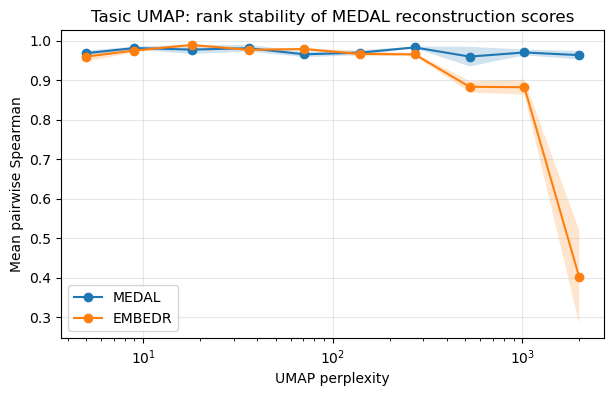

In [11]:
medal_pairwise_spearman_df, medal_mean_spearman_by_perp = summarize_rank_correlation(
    per_sample_recon_medal_all_umap
)
embedr_pairwise_spearman_df, embedr_mean_spearman_by_perp = summarize_rank_correlation(
    per_sample_recon_embedr_all_umap
)

plt.figure(figsize=(7, 4))
plt.plot(
    medal_mean_spearman_by_perp["hyperparam"],
    medal_mean_spearman_by_perp["mean_pairwise_spearman"],
    marker="o", label = 'MEDAL'
)
plt.plot(
    embedr_mean_spearman_by_perp["hyperparam"],
    embedr_mean_spearman_by_perp["mean_pairwise_spearman"],
    marker="o", label = 'EMBEDR'
)

plt.fill_between(
    medal_mean_spearman_by_perp["hyperparam"],
    medal_mean_spearman_by_perp["mean_pairwise_spearman"] - medal_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    medal_mean_spearman_by_perp["mean_pairwise_spearman"] + medal_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    alpha=0.2
)
plt.fill_between(
    embedr_mean_spearman_by_perp["hyperparam"],
    embedr_mean_spearman_by_perp["mean_pairwise_spearman"] - embedr_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    embedr_mean_spearman_by_perp["mean_pairwise_spearman"] + embedr_mean_spearman_by_perp["std_pairwise_spearman"].fillna(0),
    alpha=0.2
)
plt.xscale("log")
plt.legend()
plt.xlabel("UMAP perplexity")
plt.ylabel("Mean pairwise Spearman")
plt.title("Tasic UMAP: rank stability of MEDAL reconstruction scores")
plt.grid(True, alpha=0.3)
plt.show()

q=0.800, inter=2695, union=3391, mean_set_size=3049.0
q=0.810, inter=2553, union=3237, mean_set_size=2897.0
q=0.820, inter=2426, union=3081, mean_set_size=2744.0
q=0.830, inter=2311, union=2921, mean_set_size=2592.0
q=0.840, inter=2160, union=2760, mean_set_size=2440.0
q=0.850, inter=2028, union=2598, mean_set_size=2287.0
q=0.860, inter=1891, union=2422, mean_set_size=2135.0
q=0.870, inter=1760, union=2251, mean_set_size=1982.0
q=0.880, inter=1617, union=2081, mean_set_size=1830.0
q=0.890, inter=1492, union=1904, mean_set_size=1677.0
q=0.900, inter=1355, union=1730, mean_set_size=1525.0
q=0.910, inter=1213, union=1554, mean_set_size=1372.0
q=0.920, inter=1033, union=1420, mean_set_size=1220.0
q=0.930, inter=859, union=1288, mean_set_size=1068.0
q=0.940, inter=739, union=1103, mean_set_size=915.0
q=0.950, inter=640, union=892, mean_set_size=763.0
q=0.960, inter=550, union=670, mean_set_size=610.0
q=0.970, inter=391, union=510, mean_set_size=458.0
q=0.980, inter=173, union=419, mean_set_

q=0.900, inter=1530, union=2339, mean_set_size=1910.3
q=0.910, inter=1327, union=2162, mean_set_size=1719.7
q=0.920, inter=1127, union=1980, mean_set_size=1527.3
q=0.930, inter=936, union=1793, mean_set_size=1337.0
q=0.940, inter=753, union=1597, mean_set_size=1144.3
q=0.950, inter=552, union=1429, mean_set_size=961.0
q=0.960, inter=373, union=1230, mean_set_size=765.3
q=0.970, inter=257, union=958, mean_set_size=573.0
q=0.980, inter=174, union=660, mean_set_size=387.7
q=0.990, inter=63, union=360, mean_set_size=191.3
q=0.800, inter=3341, union=4277, mean_set_size=3816.7
q=0.810, inter=3136, union=4110, mean_set_size=3623.3
q=0.820, inter=2955, union=3932, mean_set_size=3435.0
q=0.830, inter=2745, union=3753, mean_set_size=3242.0
q=0.840, inter=2554, union=3578, mean_set_size=3051.7
q=0.850, inter=2387, union=3392, mean_set_size=2868.3
q=0.860, inter=2182, union=3212, mean_set_size=2673.7
q=0.870, inter=2019, union=3008, mean_set_size=2483.0
q=0.880, inter=1826, union=2806, mean_set_si

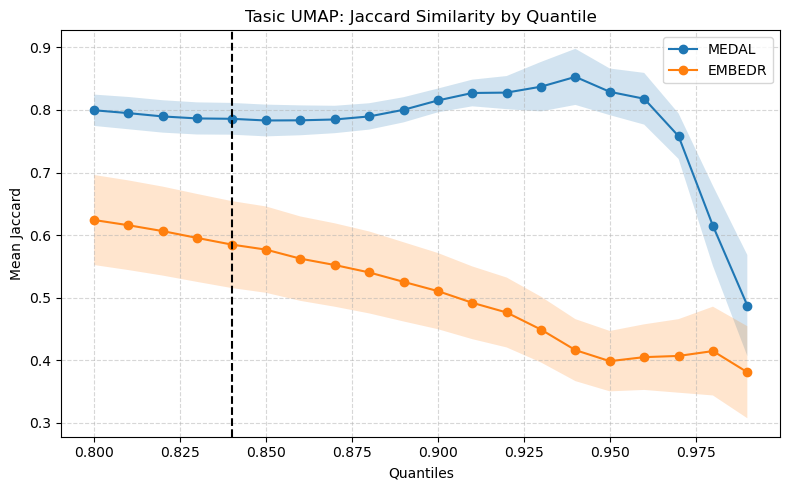

In [18]:
j3_medal_teachers, core_medal_teachers = zip(*[
    jaccard_curve(per_sample_recon_medal_all_umap[n], np.linspace(0.8, 0.99, 20))
    for n in umap_param_sweep
])
j3_medal_teachers = np.array(j3_medal_teachers)
core_medal_teachers = np.array(core_medal_teachers)

j3_embedr_teachers, core_embedr_teachers = zip(*[
    jaccard_curve(per_sample_recon_embedr_all_umap[n], np.linspace(0.8, 0.99, 20))
    for n in umap_param_sweep
])
j3_embedr_teachers = np.array(j3_embedr_teachers)
core_embedr_teachers = np.array(core_embedr_teachers)

quantiles = np.linspace(0.8, 0.99, 20)

results = {
    "MEDAL": j3_medal_teachers,
    "EMBEDR": j3_embedr_teachers,
    # "PCS": j3_pcs_teachers,
}

fig, ax = plt.subplots(figsize=(8, 5))

for label, data in results.items():
    # arr = np.stack(data)          
    means = data.mean(axis=0)      
    se = data.std(axis=0) / np.sqrt(data.shape[0])  

    ax.plot(quantiles,means, marker='o', label=label)
    ax.fill_between(quantiles, means - se, means + se, alpha=0.2)

ax.axvline(x = quantiles[4], ls = '--', c ='black')
ax.set_xlabel("Quantiles")
ax.set_ylabel("Mean Jaccard")
ax.set_title("Tasic UMAP: Jaccard Similarity by Quantile")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

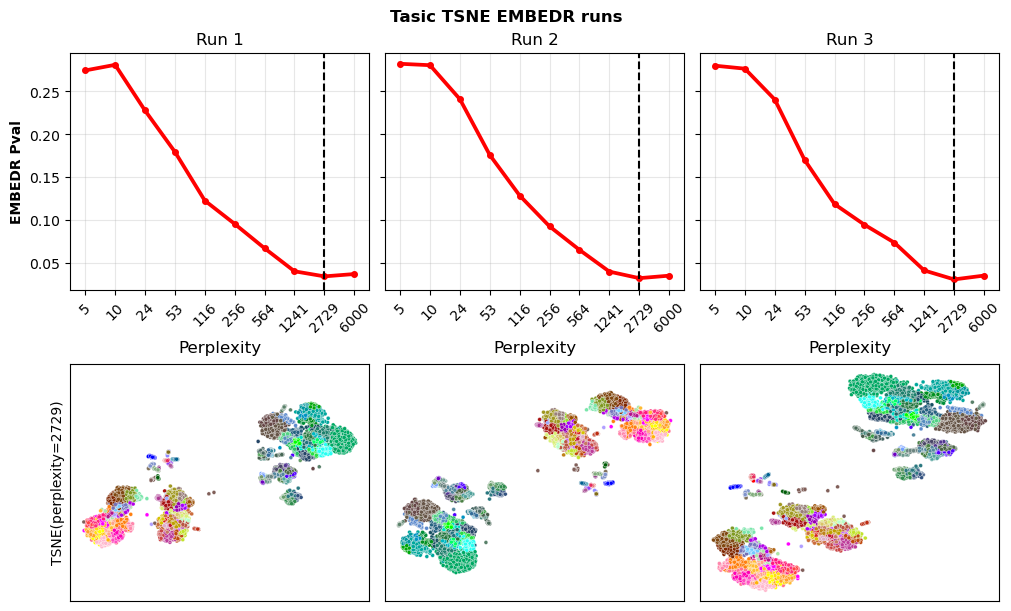

In [41]:
embedr_1_best, embedr_2_best, embedr_3_best = 2729, 2729, 2729
teacher_embed = {}
embedr_df1 = pd.read_csv(Path(PATH_PREFIX) / 'MEDAL/comparisons/results_embedr_tsne_seed0/tasic_train/X_with_best_scores.csv')
per_sample_embedr1 = embedr_df1[f'embedr_pval_meanbest_{embedr_1_best}']
embedr_df2 = pd.read_csv(Path(PATH_PREFIX) / 'MEDAL/comparisons/results_embedr_tsne_seed10/tasic_train/X_with_best_scores.csv')
per_sample_embedr2 = embedr_df2[f'embedr_pval_meanbest_{embedr_2_best}']
embedr_df3 = pd.read_csv(Path(PATH_PREFIX) / 'MEDAL/comparisons/results_embedr_tsne_seed2/tasic_train/X_with_best_scores.csv')
per_sample_embedr3 = embedr_df3[f'embedr_pval_meanbest_{embedr_3_best}']

embedr_analysis1 = pd.read_csv(Path(PATH_PREFIX) / 'MEDAL/comparisons/results_embedr_tsne_seed0/tasic_train/elbow_df.csv',  index_col = 0)
embedr_tsne_argmin = embedr_analysis1.groupby('perplexity')['mean_embedr_pval'].mean().idxmin()
argmin_position1 = embedr_analysis1.index.tolist().index(embedr_tsne_argmin)
embedr_analysis2 = pd.read_csv(Path(PATH_PREFIX) / 'MEDAL/comparisons/results_embedr_tsne_seed10/tasic_train/elbow_df.csv', index_col = 0)
embedr_tsne_argmin = embedr_analysis2.groupby('perplexity')['mean_embedr_pval'].mean().idxmin()
argmin_position2 = embedr_analysis2.index.tolist().index(embedr_tsne_argmin)
embedr_analysis3 = pd.read_csv(Path(PATH_PREFIX) / 'MEDAL/comparisons/results_embedr_tsne_seed2/tasic_train/elbow_df.csv', index_col = 0)
embedr_tsne_argmin = embedr_analysis3.groupby('perplexity')['mean_embedr_pval'].mean().idxmin()
argmin_position3 = embedr_analysis3.index.tolist().index(embedr_tsne_argmin)

fig, axes = plt.subplots(2,3, figsize=(10, 6), constrained_layout=True, sharey = 'row')
axes_flat = axes.flatten()

# 1st row 
sns.pointplot(data=embedr_analysis1, x='perplexity', y='mean_embedr_pval', color='red', markersize=3, ax = axes_flat[0])
axes_flat[0].axvline(x = argmin_position1, ls = '--', c ='black')
axes_flat[0].set_title("Run 1")
axes_flat[0].set_ylabel("EMBEDR Pval", fontweight='bold')

sns.pointplot(data=embedr_analysis2, x='perplexity', y='mean_embedr_pval', color='red', markersize=3, ax = axes_flat[1])
axes_flat[1].axvline(x = argmin_position2, ls = '--', c ='black') 
axes_flat[1].set_title("Run 2")

sns.pointplot(data=embedr_analysis3, x='perplexity', y='mean_embedr_pval', color='red', markersize=3, ax = axes_flat[2])
axes_flat[2].axvline(x = argmin_position3, ls = '--', c ='black') 
axes_flat[2].set_title("Run 3")

# 2nd row 
teacher_embed['embedr_1'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/tasic_tsne_{embedr_1_best}_0_train_embedr.npy").squeeze(0)
teacher_embed['embedr_2'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/tasic_tsne_{embedr_1_best}_10_train_embedr.npy").squeeze(0)
teacher_embed['embedr_3'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/tasic_tsne_{embedr_1_best}_2_train_embedr.npy")[0,:]
sns.scatterplot(x=teacher_embed['embedr_1'][:, 0], y=teacher_embed['embedr_1'][:, 1], 
                ax=axes_flat[3], s=8, hue=y_og, palette = tasic_palette,
                # palette=cmap, 
                # hue_norm=plt.Normalize(vmin=np.quantile(per_sample_embedr1, 0.025), vmax=np.quantile(per_sample_embedr1, 0.975)), 
                legend=False, rasterized=True)
sns.scatterplot(x=teacher_embed['embedr_2'][:, 0], y=teacher_embed['embedr_2'][:, 1], 
                ax=axes_flat[4], s=8, hue=y_og, palette = tasic_palette,
                # palette=cmap, 
                # hue_norm=plt.Normalize(vmin=np.quantile(per_sample_embedr2, 0.025), vmax=np.quantile(per_sample_embedr2, 0.975)), 
                legend=False, rasterized=True)
sns.scatterplot(x=teacher_embed['embedr_3'][:, 0], y=teacher_embed['embedr_3'][:, 1], 
                ax=axes_flat[5], s=8, hue=y_og, palette = tasic_palette,
                # palette=cmap, 
                # hue_norm=plt.Normalize(vmin=np.quantile(per_sample_embedr3, 0.025), vmax=np.quantile(per_sample_embedr3, 0.975)), 
                legend=False, rasterized=True)

axes_flat[3].set_ylabel(f"TSNE(perplexity={embedr_1_best})")
for i in [0,1,2]:
    axes_flat[i].grid(True, alpha=0.3)
    axes_flat[i].set_xlabel("Perplexity", fontsize=12)
    plt.setp(axes_flat[i].get_xticklabels(), rotation=45, ha='center')
for i in [3,4,5]:
    axes_flat[i].set_xticks([])
    axes_flat[i].set_yticks([])
fig.suptitle("Tasic TSNE EMBEDR runs", fontweight='bold')
plt.show()

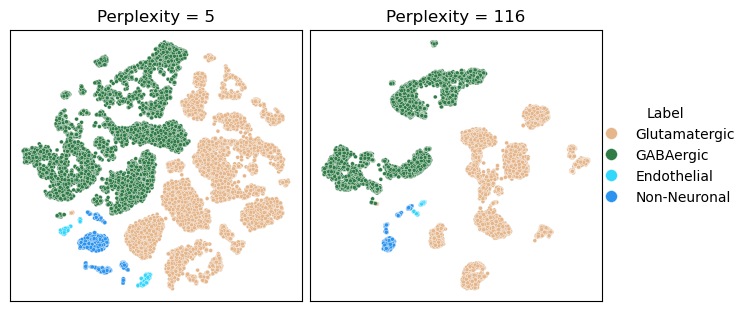

In [154]:
fig, axes = plt.subplots(1,2, figsize=(6, 3), constrained_layout=True)
axes_flat = axes.flatten()
teacher_embed = {}
teacher_embed['embedr_1'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/tasic_tsne_5_0_train.npy")
teacher_embed['embedr_2'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/tasic_tsne_116_10_train.npy")
sns.scatterplot(x=teacher_embed['embedr_1'][:, 0], y=teacher_embed['embedr_1'][:, 1], 
                ax=axes_flat[0], s=8, hue=y_class, palette = tasic_palette_class,
                legend=False, rasterized=True)
axes_flat[0].set_title("Perplexity = 5")
sns.scatterplot(x=teacher_embed['embedr_2'][:, 0], y=teacher_embed['embedr_2'][:, 1], 
                ax=axes_flat[1], s=8, hue=y_class, palette = tasic_palette_class,
                legend=True, rasterized=True)
axes_flat[1].set_title("Perplexity = 116")
handles, labels = axes_flat[1].get_legend_handles_labels()
axes_flat[1].legend_.remove()
fig.legend(handles, labels, loc='center', bbox_to_anchor=(1.1, 0.5), 
           frameon=False, title='Label', ncol=1, fontsize=10, markerscale=3, title_fontsize=10)
for ax in axes_flat:
    ax.set_xticks([])
    ax.set_yticks([])

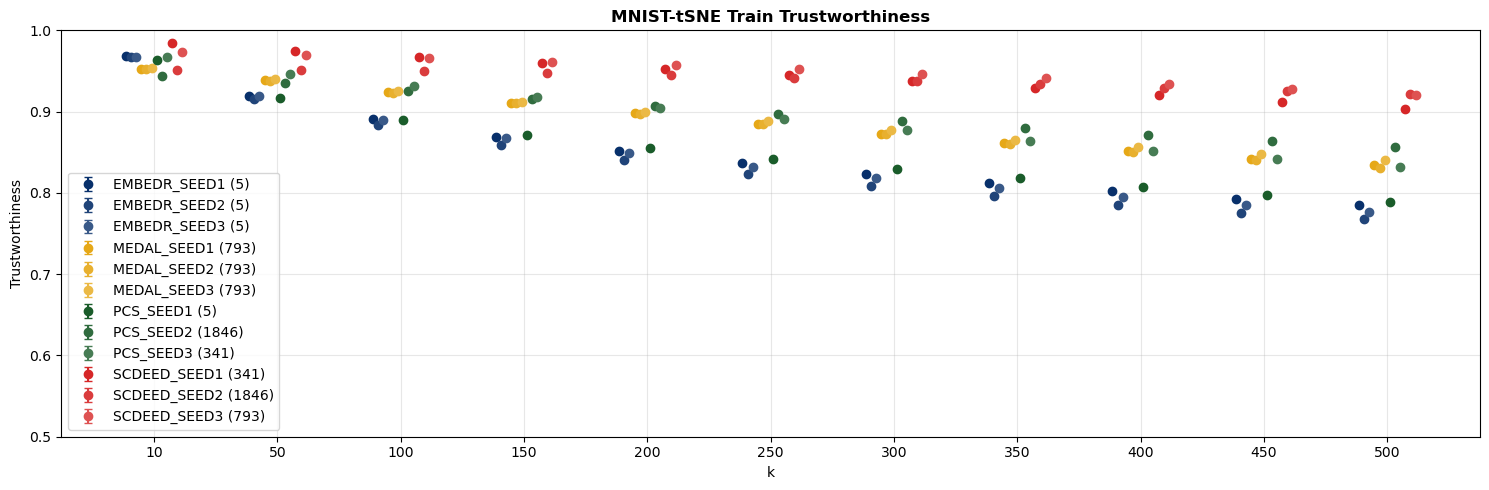

In [136]:
by_k_tsne = pd.read_csv('mnist_by_k_tsne.csv', index_col=0)
by_k_tsne = by_k_tsne.sort_values(by = ['k', "method"])
groups = by_k_tsne["k"].unique()
methods = by_k_tsne["method"].unique()

color_palette = {
    f"EMBEDR_SEED1 ({embedr_1_best})": "#08306b",
    f"EMBEDR_SEED2 ({embedr_2_best})": '#204479',
    f"EMBEDR_SEED3 ({embedr_3_best})": '#395988',
    f"PCS_SEED1 ({pcs_ss_1_best})": "#1a5c2a",
    f"PCS_SEED2 ({pcs_ss_2_best})": "#306c3f",
    f"PCS_SEED3 ({pcs_ss_3_best})": "#477c54",
    f"MEDAL_SEED1 ({medal_1_best})":   "#e6a817",
    f"MEDAL_SEED2 ({medal_2_best})": "#e8b02e",
    f"MEDAL_SEED3 ({medal_3_best})": "#ebb945",
    f"SCDEED_SEED1 ({scdeed_1_best})":  "#d62728",
    f"SCDEED_SEED2 ({scdeed_2_best})": "#da3c3d",
    f"SCDEED_SEED3 ({scdeed_3_best})": "#de5252",
}

group_gap = 1.2        
x = np.arange(len(groups)) * group_gap
z = 1.96  # 95% CI

delta = 0.05  # vertical spacing between methods
offsets = (np.arange(len(methods)) - (len(methods) - 1) / 2) * delta

plt.figure(figsize=(15, 5))

for i, m in enumerate(methods):
    sub = by_k_tsne[by_k_tsne["method"] == m].set_index("k").loc[groups]
    plt.errorbar(x=x + offsets[i], y=sub["train_tw_mean"], yerr=z * sub["train_tw_stderr"], fmt="o", capsize=3, label=m, color=color_palette[m])

plt.xticks(x, groups)
plt.ylabel("Trustworthiness")
plt.xlabel("k")
plt.ylim(0.5, 1)

# Adjust legend
# handles, labels = plt.gca().get_legend_handles_labels()
# label_map = {"EMBEDR": 'EMBEDR (5)*', 'PCS_SS': 'PCS_SS (5)*', 'SCDEED': 'SCDEED (341)***', 'MEDAL': 'MEDAL (793)**'}
# plt.legend(handles, [label_map[l] for l in labels], frameon=False)
plt.legend()

plt.grid(True, alpha=0.3)
plt.title("MNIST-tSNE Train Trustworthiness", fontweight='bold')
plt.tight_layout()
plt.show()


In [154]:
pcs_ss_1_best, pcs_ss_2_best, pcs_ss_3_best = 5, 1846, 341
scdeed_1_best, scdeed_2_best, scdeed_3_best = 341, 1846, 793
embedr_1_best, embedr_2_best, embedr_3_best = 5, 5, 5
medal_1_best, medal_2_best, medal_3_best = 793, 793, 793

teacher_embed = {}
teacher_embed['scdeed_1'] = np.load(Path(PATH_PREFIX) / f"MEDAL/comparisons/data/mnist_train_tsne_{scdeed_1_best}_0_train_pc6.npy")
teacher_embed['scdeed_2'] = np.load(Path(PATH_PREFIX) / f"MEDAL/comparisons/data/mnist_train_tsne_{scdeed_2_best}_2_train_pc6.npy")
teacher_embed['scdeed_3'] = np.load(Path(PATH_PREFIX) / f"MEDAL/comparisons/data/mnist_train_tsne_{scdeed_3_best}_10_train_pc6.npy")

teacher_embed['medal_1'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/mnist_tsne_{medal_1_best}_0_train.npy")
teacher_embed['medal_2'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/mnist_tsne_{medal_2_best}_10_train.npy")
teacher_embed['medal_3'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/mnist_tsne_{medal_3_best}_2_train.npy")

teacher_embed['embedr_1'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/mnist_tsne_{embedr_1_best}_0_train_embedr.npy").squeeze(0)
teacher_embed['embedr_2'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/mnist_tsne_{embedr_2_best}_10_train_embedr.npy").squeeze(0)
teacher_embed['embedr_3'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/mnist_tsne_{embedr_3_best}_2_train_embedr.npy").squeeze(0)

teacher_embed['pcs_ss_1'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/mnist_tsne_{pcs_ss_1_best}_0_train_pcs.npy")
teacher_embed['pcs_ss_2'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/mnist_tsne_{pcs_ss_2_best}_2_train_pcs.npy")
teacher_embed['pcs_ss_3'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/mnist_tsne_{pcs_ss_3_best}_10_train_pcs.npy")

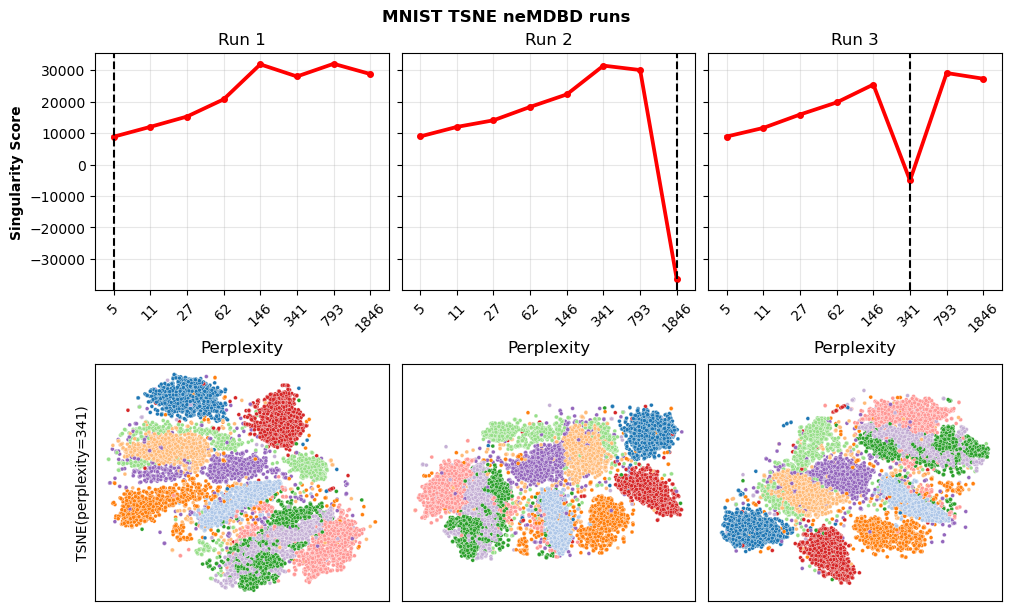

In [181]:
pcs_1_best, pcs_2_best, pcs_3_best = 5, 1846, 341
teacher_embed = {}
pcs_df1 = pd.read_csv(Path(PATH_PREFIX) / 'MEDAL/comparisons/results_pcs_seed0/mnist_train/X_with_best_scores.csv')
per_sample_pcs1 = pcs_df1[f'sscore_meanbest_{pcs_1_best}']
pcs_df2 = pd.read_csv(Path(PATH_PREFIX) / 'MEDAL/comparisons/results_pcs_seed2/mnist_train/X_with_best_scores.csv')
per_sample_pcs2 = pcs_df2[f'sscore_meanbest_{pcs_2_best}']
pcs_df3 = pd.read_csv(Path(PATH_PREFIX) / 'MEDAL/comparisons/results_pcs_seed10/mnist_train/X_with_best_scores.csv')
per_sample_pcs3 = pcs_df3[f'sscore_meanbest_{pcs_3_best}']

pcs_analysis1 = pd.read_csv(Path(PATH_PREFIX) / 'MEDAL/comparisons/results_pcs_seed0/mnist_train/elbow_df.csv',  index_col = 0)
pcs_tsne_argmin = pcs_analysis1.groupby('perplexity')['mean_sscore'].mean().idxmin()
argmin_position1 = pcs_analysis1.index.tolist().index(pcs_tsne_argmin)
pcs_analysis2 = pd.read_csv(Path(PATH_PREFIX) / 'MEDAL/comparisons/results_pcs_seed2/mnist_train/elbow_df.csv', index_col = 0)
pcs_tsne_argmin = pcs_analysis2.groupby('perplexity')['mean_sscore'].mean().idxmin()
argmin_position2 = pcs_analysis2.index.tolist().index(pcs_tsne_argmin)
pcs_analysis3 = pd.read_csv(Path(PATH_PREFIX) / 'MEDAL/comparisons/results_pcs_seed10/mnist_train/elbow_df.csv', index_col = 0)
pcs_tsne_argmin = pcs_analysis3.groupby('perplexity')['mean_sscore'].mean().idxmin()
argmin_position3 = pcs_analysis3.index.tolist().index(pcs_tsne_argmin)

fig, axes = plt.subplots(2,3, figsize=(10, 6), constrained_layout=True, sharey = 'row')
axes_flat = axes.flatten()

# 1st row 
sns.pointplot(data=pcs_analysis1, x='perplexity', y='mean_sscore', color='red', markersize=3, ax = axes_flat[0])
axes_flat[0].axvline(x = argmin_position1, ls = '--', c ='black')
axes_flat[0].set_title("Run 1")
axes_flat[0].set_ylabel("Singularity Score", fontweight='bold')

sns.pointplot(data=pcs_analysis2, x='perplexity', y='mean_sscore', color='red', markersize=3, ax = axes_flat[1])
axes_flat[1].axvline(x = argmin_position2, ls = '--', c ='black') 
axes_flat[1].set_title("Run 2")

sns.pointplot(data=pcs_analysis3, x='perplexity', y='mean_sscore', color='red', markersize=3, ax = axes_flat[2])
axes_flat[2].axvline(x = argmin_position3, ls = '--', c ='black') 
axes_flat[2].set_title("Run 3")

# # 2nd row 
teacher_embed['pcs_1'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/mnist_tsne_{pcs_3_best}_0_train_pcs.npy")
teacher_embed['pcs_2'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/mnist_tsne_{pcs_3_best}_2_train_pcs.npy")
teacher_embed['pcs_3'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/mnist_tsne_{pcs_3_best}_10_train_pcs.npy")
sns.scatterplot(x=teacher_embed['pcs_1'][:, 0], y=teacher_embed['pcs_1'][:, 1], 
                ax=axes_flat[3], s=8, hue=y_og, palette = mnist_palette,
                # palette=cmap, 
                # hue_norm=plt.Normalize(vmin=np.quantile(per_sample_pcs1, 0.025), vmax=np.quantile(per_sample_pcs1, 0.975)), 
                legend=False, rasterized=True)
sns.scatterplot(x=teacher_embed['pcs_2'][:, 0], y=teacher_embed['pcs_2'][:, 1], 
                ax=axes_flat[4], s=8, hue=y_og, palette = mnist_palette,
                # palette=cmap, 
                # hue_norm=plt.Normalize(vmin=np.quantile(per_sample_pcs2, 0.025), vmax=np.quantile(per_sample_pcs2, 0.975)), 
                legend=False, rasterized=True)
sns.scatterplot(x=teacher_embed['pcs_3'][:, 0], y=teacher_embed['pcs_3'][:, 1], 
                ax=axes_flat[5], s=8, hue=y_og, palette = mnist_palette,
                # palette=cmap, 
                # hue_norm=plt.Normalize(vmin=np.quantile(per_sample_pcs3, 0.025), vmax=np.quantile(per_sample_pcs3, 0.975)), 
                legend=False, rasterized=True)
axes_flat[3].set_ylabel(f"TSNE(perplexity={pcs_3_best})")

for i in [0,1,2]:
    axes_flat[i].grid(True, alpha=0.3)
    axes_flat[i].set_xlabel("Perplexity", fontsize=12)
    plt.setp(axes_flat[i].get_xticklabels(), rotation=45, ha='center')
for ax in axes_flat[3:]:
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle("MNIST TSNE neMDBD runs", fontweight='bold')
plt.show()

In [69]:
from utils import evaluate_methods
seed_list = [0,2,10]
scdeed_best = {
    "tsne": {0: 341, 2: 1846, 10: 793},
    "umap": {0: 499, 2: 5,    10: 5}
}
embedr_best = {
    "tsne": {0: 5,   2: 5,   10: 5},
    "umap": {0: 499, 2: 499, 10: 499}
}
medal_1_best, medal_2_best, medal_3_best = 49, 18, 18

teacher_embed = {}
teacher_embed['scdeed_1'] = np.load(Path(PATH_PREFIX) / f"MEDAL/comparisons/data/mnist_train_umap_{scdeed_best['umap'][0]}_0.1_0_train_pc6.npy")
teacher_embed['scdeed_2'] = np.load(Path(PATH_PREFIX) / f"MEDAL/comparisons/data/mnist_train_umap_{scdeed_best['umap'][2]}_0.1_2_train_pc6.npy")
teacher_embed['scdeed_3'] = np.load(Path(PATH_PREFIX) / f"MEDAL/comparisons/data/mnist_train_umap_{scdeed_best['umap'][10]}_0.1_10_train_pc6.npy")

teacher_embed['medal_1'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/mnist_umap_{medal_1_best}_0.1_0_train.npy")
teacher_embed['medal_2'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/mnist_umap_{medal_2_best}_0.1_10_train.npy")
teacher_embed['medal_3'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/mnist_umap_{medal_3_best}_0.1_2_train.npy")

teacher_embed['embedr_1'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/mnist_umap_{embedr_best['umap'][0]}_0.1_0_train_embedr.npy").squeeze(0)
teacher_embed['embedr_2'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/mnist_umap_{embedr_best['umap'][2]}_0.1_2_train_embedr.npy").squeeze(0)
teacher_embed['embedr_3'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/mnist_umap_{embedr_best['umap'][10]}_0.1_10_train_embedr.npy").squeeze(0)

umap_acc_df = pd.concat([
    evaluate_methods(
        {
            f"EMBEDR_SEED1 ({embedr_best['umap'][0]})":  (teacher_embed["embedr_1"], None),
            f"EMBEDR_SEED2 ({embedr_best['umap'][2]})":  (teacher_embed["embedr_2"], None),
            f"EMBEDR_SEED3 ({embedr_best['umap'][10]})":  (teacher_embed["embedr_3"], None),
            f"SCDEED_SEED1 ({scdeed_best['umap'][0]})": (teacher_embed["scdeed_1"], None),
            f"SCDEED_SEED2 ({scdeed_best['umap'][2]})": (teacher_embed["scdeed_2"], None),
            f"SCDEED_SEED3 ({scdeed_best['umap'][10]})": (teacher_embed["scdeed_3"], None),
        },
        y_og, None, cv = 5, random_state = 0, return_estimators = True)[0],
    evaluate_methods(
        {
            f"MEDAL_SEED1 ({medal_1_best})":  (teacher_embed["medal_1"], None), 
            f"MEDAL_SEED2 ({medal_2_best})":  (teacher_embed["medal_2"], None), 
            f"MEDAL_SEED3 ({medal_3_best})":  (teacher_embed["medal_3"], None), 
        },
        y, None, cv = 5, random_state = 0, return_estimators = True)[0],
])

umap_acc_df

,train_accuracy,train_accuracy_std,train_macro_f1,train_macro_f1_std,test_accuracy,test_accuracy_std,test_macro_f1,test_macro_f1_std
method,,,,,,,,
EMBEDR_SEED1 (499),0.999938,0.000077,0.999934,0.000081,0.804125,0.010098,0.798887,0.010593
EMBEDR_SEED3 (499),0.999906,0.000125,0.999900,0.000135,0.801000,0.005341,0.795053,0.004811
EMBEDR_SEED2 (499),0.999844,0.000242,0.999837,0.000250,0.797250,0.003504,0.791296,0.004185
SCDEED_SEED2 (5),0.999938,0.000125,0.999937,0.000127,0.751750,0.008582,0.746413,0.008877
SCDEED_SEED3 (5),0.999906,0.000077,0.999908,0.000076,0.744750,0.009703,0.739207,0.008487
SCDEED_SEED1 (499),0.999938,0.000077,0.999932,0.000083,0.678000,0.010785,0.668506,0.010822
MEDAL_SEED2 (18),0.999922,0.000156,0.999925,0.000150,0.910781,0.006836,0.908738,0.006905
MEDAL_SEED3 (18),0.999883,0.000096,0.999879,0.000099,0.905781,0.009052,0.903292,0.009008
MEDAL_SEED1 (49),0.999883,0.000156,0.999886,0.000154,0.871250,0.005399,0.866944,0.005231


In [70]:
pcs_ss_1_best, pcs_ss_2_best, pcs_ss_3_best = 5, 1846, 341
medal_1_best, medal_2_best, medal_3_best = 793, 793, 793

teacher_embed = {}
teacher_embed['scdeed_1'] = np.load(Path(PATH_PREFIX) / f"MEDAL/comparisons/data/mnist_train_tsne_{scdeed_best['tsne'][0]}_0_train_pc6.npy")
teacher_embed['scdeed_2'] = np.load(Path(PATH_PREFIX) / f"MEDAL/comparisons/data/mnist_train_tsne_{scdeed_best['tsne'][2]}_2_train_pc6.npy")
teacher_embed['scdeed_3'] = np.load(Path(PATH_PREFIX) / f"MEDAL/comparisons/data/mnist_train_tsne_{scdeed_best['tsne'][10]}_10_train_pc6.npy")

teacher_embed['medal_1'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/mnist_tsne_{medal_1_best}_0_train.npy")
teacher_embed['medal_2'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/mnist_tsne_{medal_2_best}_10_train.npy")
teacher_embed['medal_3'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/mnist_tsne_{medal_3_best}_2_train.npy")

teacher_embed['embedr_1'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/mnist_tsne_{embedr_best['tsne'][0]}_0_train_embedr.npy").squeeze(0)
teacher_embed['embedr_2'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/mnist_tsne_{embedr_best['tsne'][2]}_2_train_embedr.npy").squeeze(0)
teacher_embed['embedr_3'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/mnist_tsne_{embedr_best['tsne'][10]}_10_train_embedr.npy").squeeze(0)

teacher_embed['pcs_ss_1'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/mnist_tsne_{pcs_ss_1_best}_0_train_pcs.npy")
teacher_embed['pcs_ss_2'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/mnist_tsne_{pcs_ss_2_best}_2_train_pcs.npy")
teacher_embed['pcs_ss_3'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/mnist_tsne_{pcs_ss_3_best}_10_train_pcs.npy")

tsne_acc_df = pd.concat([
    evaluate_methods(
        {
            f"EMBEDR_SEED1 ({embedr_best['tsne'][0]})":  (teacher_embed["embedr_1"], None),
            f"EMBEDR_SEED2 ({embedr_best['tsne'][2]})":  (teacher_embed["embedr_2"], None),
            f"EMBEDR_SEED3 ({embedr_best['tsne'][10]})":  (teacher_embed["embedr_3"], None),
            f"SCDEED_SEED1 ({scdeed_best['tsne'][0]})": (teacher_embed["scdeed_1"], None),
            f"SCDEED_SEED2 ({scdeed_best['tsne'][2]})": (teacher_embed["scdeed_2"], None),
            f"SCDEED_SEED3 ({scdeed_best['tsne'][10]})": (teacher_embed["scdeed_3"], None),
            f"PCS_SEED1 ({pcs_ss_1_best})": (teacher_embed["pcs_ss_1"], None),
            f"PCS_SEED2 ({pcs_ss_2_best})": (teacher_embed["pcs_ss_2"], None),
            f"PCS_SEED3 ({pcs_ss_3_best})": (teacher_embed["pcs_ss_3"], None),
        },
        y_og, None, cv = 5, random_state = 0, return_estimators = True)[0],
    evaluate_methods(
        {
            f"MEDAL_SEED1 ({medal_1_best})":  (teacher_embed["medal_1"], None), 
            f"MEDAL_SEED2 ({medal_2_best})":  (teacher_embed["medal_2"], None), 
            f"MEDAL_SEED3 ({medal_3_best})":  (teacher_embed["medal_3"], None), 
        },
        y, None, cv = 5, random_state = 0, return_estimators = True)[0],
])

tsne_acc_df

,train_accuracy,train_accuracy_std,train_macro_f1,train_macro_f1_std,test_accuracy,test_accuracy_std,test_macro_f1,test_macro_f1_std
method,,,,,,,,
EMBEDR_SEED1 (5),0.999875,0.000153,0.999866,0.000164,0.942250,0.006808,0.941474,0.006573
EMBEDR_SEED2 (5),0.999844,0.000140,0.999834,0.000150,0.942125,0.004305,0.941065,0.004492
EMBEDR_SEED3 (5),0.999844,0.000099,0.999833,0.000108,0.939500,0.004633,0.938649,0.004791
PCS_SEED1 (5),0.999844,0.000099,0.999830,0.000108,0.939375,0.003558,0.938488,0.003551
PCS_SEED3 (341),0.999969,0.000062,0.999966,0.000068,0.917375,0.003172,0.915901,0.002860
PCS_SEED2 (1846),0.999875,0.000062,0.999871,0.000065,0.765000,0.012924,0.759641,0.012863
SCDEED_SEED1 (341),0.999844,0.000140,0.999841,0.000142,0.740250,0.011643,0.734154,0.011720
SCDEED_SEED3 (793),0.999906,0.000077,0.999898,0.000083,0.679750,0.012258,0.670833,0.012029
SCDEED_SEED2 (1846),0.999969,0.000062,0.999971,0.000058,0.585500,0.007920,0.573425,0.007446


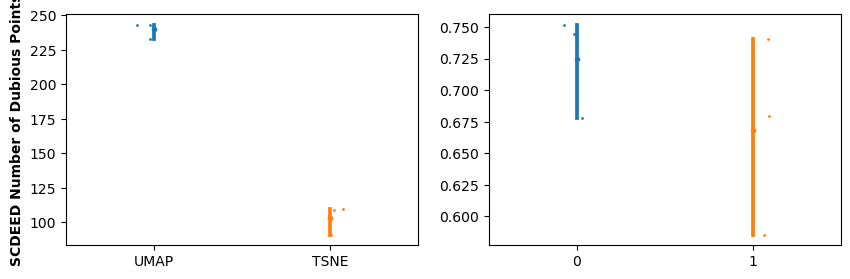

In [71]:
# SCDEED
teacher_embed = {}
per_sample_embedr, analysis = {s: [] for s in ["tsne", "umap"]}, {s: [] for s in ["tsne", "umap"]}
seed_list = [0,2,10]
for seed in seed_list:
    for m, hyperparam in zip(["tsne", "umap"], ["perplexity", "n_neighbors"]):
        df = pd.read_csv(Path(PATH_PREFIX) / f'MEDAL/comparisons/results_scdeed_{m}/seed{seed}/{m}_best_mnist_train_full_results.csv', index_col=0)
        per_sample_embedr[m].append(split_scdeed_labels(df, scdeed_best[m][seed])['label']) 

        tune = pd.read_csv(Path(PATH_PREFIX) / f'MEDAL/comparisons/results_scdeed_{m}/seed{seed}/{m}_best_mnist_train_num_dubious.csv')
        min_val = tune.groupby(hyperparam)['number_dubious_cells'].mean().min()
        min_hyperparam = tune.groupby(hyperparam)['number_dubious_cells'].mean().idxmin()
        analysis[m].append((tune, min_val, min_hyperparam))

fig, axes = plt.subplots(1, 2, figsize=(10,3))
ax = axes[0]
for m_id, m in enumerate(["umap", "tsne"]):
    values = [analysis[m][s][1] for s in range(3)]
    sns.pointplot(x = [m_id] * 3, y = values, markersize=2,ax = ax)
    sns.stripplot(x = [m_id] * 3, y = values, size=2,ax = ax)
ax.set_xticks([0, 1], ["UMAP", "TSNE"])
ax.set_ylabel("SCDEED Number of Dubious Points", fontweight='bold')

ax = axes[1]
for m_id, (m, acc_df) in enumerate(zip(["umap", "tsne"], [umap_acc_df, tsne_acc_df])):
    values = [acc_df.loc[f"SCDEED_SEED{s_id + 1} ({scdeed_best[m][s]})", "test_accuracy"] for s_id, s in enumerate(seed_list)] 
    sns.pointplot(x = [m_id] * 3, y = values, markersize=2, ax = ax)
    sns.stripplot(x = [m_id] * 3, y = values, size=2, ax = ax)
    
plt.show()

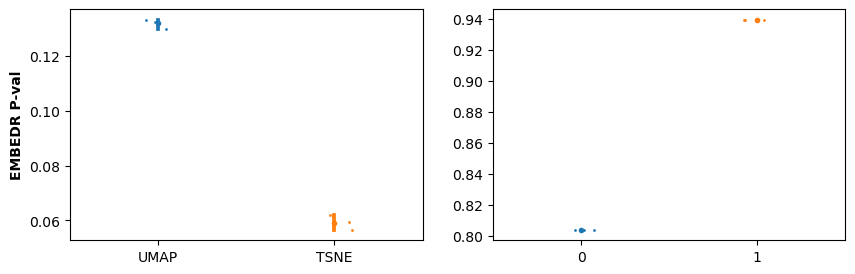

In [62]:
teacher_embed = {}
embedr_best = {
    "tsne": {0: 5,   2: 5,   10: 5},
    "umap": {0: 499, 2: 499, 10: 499}
}
per_sample_embedr, analysis = {s: [] for s in ["tsne", "umap"]}, {s: [] for s in ["tsne", "umap"]}
seed_list = [0,2,10]
for seed in seed_list:
    for m, hyperparam in zip(["tsne", "umap"], ["perplexity", "n_neighbors"]):
        df = pd.read_csv(Path(PATH_PREFIX) / f'MEDAL/comparisons/results_embedr_{m}_seed{seed}/mnist_train/X_with_best_scores.csv')
        per_sample_embedr[m].append(df[f'embedr_pval_meanbest_{embedr_best[m][seed]}']) 

        tune = pd.read_csv(Path(PATH_PREFIX) / f'MEDAL/comparisons/results_embedr_{m}_seed{seed}/mnist_train/elbow_df.csv',  index_col = 0)
        min_val = tune.groupby(hyperparam)['mean_embedr_pval'].mean().min()
        min_hyperparam = tune.groupby(hyperparam)['mean_embedr_pval'].mean().idxmin()
        analysis[m].append((tune, min_val, min_hyperparam))

fig, axes = plt.subplots(1, 2, figsize=(10,3))
ax = axes[0]
for m_id, m in enumerate(["umap", "tsne"]):
    values = [analysis[m][s][1] for s in range(3)]
    sns.pointplot(x = [m_id] * 3, y = values, markersize=2, ax = ax)
    sns.stripplot(x = [m_id] * 3, y = values, size=2, ax = ax)
ax.set_xticks([0, 1], ["UMAP", "TSNE"])
ax.set_ylabel("EMBEDR P-val", fontweight='bold')

ax = axes[1]
for m_id, (m, acc_df) in enumerate(zip(["umap", "tsne"], [umap_acc_df, tsne_acc_df])):
    values = [acc_df.loc[f"EMBEDR_SEED{m_id + 1} ({embedr_best[m][s]})", "test_accuracy"] for s in seed_list] 
    sns.pointplot(x = [m_id] * 3, y = values, markersize=2, ax = ax)
    sns.stripplot(x = [m_id] * 3, y = values, size=2, ax = ax)

plt.show()


In [1]:
import sys
sys.path.insert(0, "/share/ctn/users/bnc2119/MEDAL/ltnc/src/ltnc/")  # goes in first → ends at index 1
sys.path.insert(0, "/share/ctn/users/bnc2119/MEDAL/ltnc/src/")        # goes in second → ends at index 0

from ltnc import ltnc

Label-Trustworthiness (LT): 0.9972475580848912
Label-Continuity (LC): 0.9999460156313276


In [14]:
pcs_ss_1_best, pcs_ss_2_best, pcs_ss_3_best = 5, 1846, 341
medal_1_best, medal_2_best, medal_3_best = 793, 793, 793
scdeed_best = {
    "tsne": {0: 341, 2: 1846, 10: 793},
    "umap": {0: 499, 2: 5,    10: 5}
}
embedr_best = {
    "tsne": {0: 5,   2: 5,   10: 5},
    "umap": {0: 499, 2: 499, 10: 499}
}

teacher_embed = {}
teacher_embed['scdeed_1'] = np.load(Path(PATH_PREFIX) / f"MEDAL/comparisons/data/mnist_train_tsne_{scdeed_best['tsne'][0]}_0_train_pc6.npy")
teacher_embed['scdeed_2'] = np.load(Path(PATH_PREFIX) / f"MEDAL/comparisons/data/mnist_train_tsne_{scdeed_best['tsne'][2]}_2_train_pc6.npy")
teacher_embed['scdeed_3'] = np.load(Path(PATH_PREFIX) / f"MEDAL/comparisons/data/mnist_train_tsne_{scdeed_best['tsne'][10]}_10_train_pc6.npy")

teacher_embed['medal_1'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/mnist_tsne_{medal_1_best}_0_train.npy")
teacher_embed['medal_2'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/mnist_tsne_{medal_2_best}_10_train.npy")
teacher_embed['medal_3'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/mnist_tsne_{medal_3_best}_2_train.npy")

teacher_embed['embedr_1'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/mnist_tsne_{embedr_best['tsne'][0]}_0_train_embedr.npy").squeeze(0)
teacher_embed['embedr_2'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/mnist_tsne_{embedr_best['tsne'][2]}_2_train_embedr.npy").squeeze(0)
teacher_embed['embedr_3'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/mnist_tsne_{embedr_best['tsne'][10]}_10_train_embedr.npy").squeeze(0)

teacher_embed['pcs_ss_1'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/mnist_tsne_{pcs_ss_1_best}_0_train_pcs.npy")
teacher_embed['pcs_ss_2'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/mnist_tsne_{pcs_ss_2_best}_2_train_pcs.npy")
teacher_embed['pcs_ss_3'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/mnist_tsne_{pcs_ss_3_best}_10_train_pcs.npy")

X_scdeed = pd.read_csv(Path(PATH_PREFIX) / f"MEDAL/comparisons/data/mnist_train_pc6.csv", index_col=0)

# Define which keys are medal embeddings
medal_keys = {'medal_1', 'medal_2', 'medal_3'}
scdeed_keys = {'scdeed_1', 'scdeed_2', 'scdeed_3'}

results_list = []

for key, embedding in teacher_embed.items():
    # Use X and y for medal embeddings, X_og and y_og for others
    if key in medal_keys:
        raw_data = X
        labels = y
    elif key in scdeed_keys:
        raw_data = X_scdeed
        labels = y_og
    else:
        raw_data = X_og
        labels = y_og

    label_tnc = ltnc.LabelTNC(raw_data, embedding, labels, cvm="btw_ch")
    results = label_tnc.run()

    results_list.append({
        "method": key,
        "LT": results["lt"],
        "LC": results["lc"]
    })

df_results = pd.DataFrame(results_list).set_index("method")
print(df_results)

                LT        LC
method                      
scdeed_1  0.885918  0.994083
scdeed_2  0.857537  0.997488
scdeed_3  0.846930  0.998347
medal_1   0.964099  0.861474
medal_2   0.954267  0.864736
medal_3   0.926243  0.878935
embedr_1  0.970773  0.875198
embedr_2  0.985416  0.898000
embedr_3  0.922996  0.904366
pcs_ss_1  0.974995  0.900567
pcs_ss_2  0.920545  0.914666
pcs_ss_3  0.957291  0.896380


In [25]:
test_embeddings = {}
val_embeddings = {}
for s in range(2):
    for perp in [    5,    11,    27,    62,   146,   341,   793,  1846]:
        teacher_embed = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/mnist_tsne_{perp}_0_train.npy")
        student = load_trained_ae(Path(PATH_PREFIX) / f"drd_data/tmp_results/chkpt_w_val/mnist/medal_tsne2_{perp}_{s}_ckpts/final.pt",
                input_dim=784,
                hidden_dims=[512, 512, 512, 512],
                latent_dim=2, activation=torch.nn.SELU, batchnorm=False)
        
        student_recon, student_embed = student(torch.tensor(X, dtype=torch.float32))
        train_distill = np.mean((teacher_embed - student_embed.detach().numpy()) ** 2)
        if train_distill < 1e-5:
            
            _, val_embed = student(torch.tensor(X_val, dtype=torch.float32))

            _, test_embed = student(torch.tensor(X_test, dtype=torch.float32))
            
            test_embeddings[f"tsne{perp}_{s}"] = test_embed
            val_embeddings[f"tsne{perp}_{s}"]  = val_embed
        else:
            print(f"Skipping param {perp} seed {s} due to distillation loss {train_distill}")

/tmp/ipykernel_20232/451100238.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt_path, map_location="cpu")


loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded params: 20 | missing=0 | unexpected=0
loaded par

In [28]:
results_list = []

for key, embedding in test_embeddings.items():

    label_tnc = ltnc.LabelTNC(X_test, embedding.detach().numpy(), y_test, cvm="btw_ch")
    results = label_tnc.run()

    results_list.append({
        "method": key,
        "LT": results["lt"],
        "LC": results["lc"]
    })
    
df_results = pd.DataFrame(results_list).set_index("method")
print(df_results.sort_values('LC'))

                  LT        LC
method                        
tsne5_2     0.998995  0.653371
tsne62_2    0.991865  0.654347
tsne27_0    0.994699  0.654600
tsne27_4    0.994205  0.655375
tsne62_3    0.992661  0.655844
tsne27_2    0.994082  0.656045
tsne27_3    0.994378  0.656296
tsne5_3     0.997836  0.656751
tsne62_1    0.991126  0.657016
tsne62_4    0.991653  0.657888
tsne27_1    0.994598  0.659008
tsne62_0    0.991961  0.659405
tsne5_0     0.997905  0.659545
tsne5_4     0.998036  0.659818
tsne5_1     0.997616  0.660061
tsne11_1    0.998179  0.666999
tsne11_4    0.998762  0.667187
tsne11_2    0.997684  0.667612
tsne11_3    0.997201  0.668203
tsne11_0    0.998383  0.670867
tsne793_3   0.984893  0.676291
tsne793_2   0.984757  0.678021
tsne793_1   0.983912  0.678531
tsne146_2   0.989890  0.678561
tsne793_0   0.984138  0.678991
tsne146_4   0.988284  0.679739
tsne793_4   0.983877  0.680195
tsne146_1   0.987954  0.681723
tsne146_3   0.986102  0.684469
tsne146_0   0.986521  0.684945
tsne1846

In [29]:
print(df_results.sort_values('LT'))

                  LT        LC
method                        
tsne1846_0  0.963207  0.717455
tsne1846_2  0.963565  0.715955
tsne1846_4  0.964302  0.714597
tsne1846_3  0.964317  0.715218
tsne1846_1  0.965714  0.714540
tsne793_4   0.983877  0.680195
tsne793_1   0.983912  0.678531
tsne793_0   0.984138  0.678991
tsne793_2   0.984757  0.678021
tsne793_3   0.984893  0.676291
tsne341_4   0.985234  0.721229
tsne341_2   0.985428  0.721155
tsne341_3   0.985439  0.722867
tsne341_0   0.985633  0.721846
tsne341_1   0.985960  0.722999
tsne146_3   0.986102  0.684469
tsne146_0   0.986521  0.684945
tsne146_1   0.987954  0.681723
tsne146_4   0.988284  0.679739
tsne146_2   0.989890  0.678561
tsne62_1    0.991126  0.657016
tsne62_4    0.991653  0.657888
tsne62_2    0.991865  0.654347
tsne62_0    0.991961  0.659405
tsne62_3    0.992661  0.655844
tsne27_2    0.994082  0.656045
tsne27_4    0.994205  0.655375
tsne27_3    0.994378  0.656296
tsne27_1    0.994598  0.659008
tsne27_0    0.994699  0.654600
tsne11_3

In [11]:

medal_1_best, medal_2_best, medal_3_best = 4999, 2320, 2320
scdeed_best = {
    "tsne": {0: 4999, 2: 4999, 10: 4999},
#     "umap": {0: 499, 2: 5,    10: 5}
}
embedr_best = {
    "tsne": {0: 4999,   2: 4999,   10: 4999},
#     "umap": {0: 499, 2: 499, 10: 499}
}
pcs_best = {
    "tsne": {0: 5,   2: 5,   10: 5},
}

teacher_embed = {}
teacher_embed['scdeed_1'] = np.load(Path(PATH_PREFIX) / f"MEDAL/comparisons/data/hydra_train_tsne_{scdeed_best['tsne'][0]}_0_train_pc4.npy")
teacher_embed['scdeed_2'] = np.load(Path(PATH_PREFIX) / f"MEDAL/comparisons/data/hydra_train_tsne_{scdeed_best['tsne'][2]}_2_train_pc4.npy")
teacher_embed['scdeed_3'] = np.load(Path(PATH_PREFIX) / f"MEDAL/comparisons/data/hydra_train_tsne_{scdeed_best['tsne'][10]}_10_train_pc4.npy")

teacher_embed['medal_1'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/hydra_tsne_{medal_1_best}_0_train.npy")
teacher_embed['medal_2'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/hydra_tsne_{medal_2_best}_2_train.npy")
teacher_embed['medal_3'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/hydra_tsne_{medal_3_best}_10_train.npy")

teacher_embed['embedr_1'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/hydra_tsne_{embedr_best['tsne'][0]}_0_train_embedr.npy").squeeze(0)
teacher_embed['embedr_2'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/hydra_tsne_{embedr_best['tsne'][2]}_2_train_embedr.npy").squeeze(0)
teacher_embed['embedr_3'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/hydra_tsne_{embedr_best['tsne'][10]}_10_train_embedr.npy").squeeze(0)

teacher_embed['pcs_ss_1'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/hydra_tsne_{pcs_best['tsne'][0]}_0_train_pcs.npy")
teacher_embed['pcs_ss_2'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/hydra_tsne_{pcs_best['tsne'][2]}_2_train_pcs.npy")
teacher_embed['pcs_ss_3'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/hydra_tsne_{pcs_best['tsne'][10]}_10_train_pcs.npy")

X_scdeed = pd.read_csv(Path(PATH_PREFIX) / f"MEDAL/comparisons/data/hydra_train_pc4.csv", index_col=0)
# Define which keys are medal embeddings
medal_keys = {'medal_1', 'medal_2', 'medal_3'}
scdeed_keys = {'scdeed_1', 'scdeed_2', 'scdeed_3'}

results_list = []

for key, embedding in teacher_embed.items():
    # Use X and y for medal embeddings, X_og and y_og for others
    if key in medal_keys:
        raw_data = X
        labels = y
    elif key in scdeed_keys:
        raw_data = X_scdeed
        labels = y_og
    else:
        raw_data = X_og
        labels = y_og

    label_tnc = ltnc.LabelTNC(raw_data, embedding, labels, cvm="btw_ch")
    results = label_tnc.run()

    results_list.append({
        "method": key,
        "LT": results["lt"],
        "LC": results["lc"]
    })

df_results = pd.DataFrame(results_list).set_index("method")
print(df_results)

                LT        LC
method                      
scdeed_1  0.896916  0.994469
scdeed_2  0.862965  0.995137
scdeed_3  0.857406  0.995384
medal_1   0.882538  0.988281
medal_2   0.870950  0.984888
medal_3   0.862375  0.987556
embedr_1  0.883180  0.989441
embedr_2  0.886980  0.989282
embedr_3  0.879351  0.989441
pcs_ss_1  0.911299  0.984442
pcs_ss_2  0.872106  0.984326
pcs_ss_3  0.837827  0.987196


In [ ]:

medal_1_best, medal_2_best, medal_3_best = 4999, 2320, 2320
scdeed_best = {
    "tsne": {0: 4999, 2: 4999, 10: 4999},
#     "umap": {0: 499, 2: 5,    10: 5}
}
embedr_best = {
    "tsne": {0: 4999,   2: 4999,   10: 4999},
#     "umap": {0: 499, 2: 499, 10: 499}
}
pcs_best = {
    "tsne": {0: 5,   2: 5,   10: 5},
}

teacher_embed = {}
teacher_embed['scdeed_1'] = np.load(Path(PATH_PREFIX) / f"MEDAL/comparisons/data/hydra_train_tsne_{scdeed_best['tsne'][0]}_0_train_pc4.npy")
teacher_embed['scdeed_2'] = np.load(Path(PATH_PREFIX) / f"MEDAL/comparisons/data/hydra_train_tsne_{scdeed_best['tsne'][2]}_2_train_pc4.npy")
teacher_embed['scdeed_3'] = np.load(Path(PATH_PREFIX) / f"MEDAL/comparisons/data/hydra_train_tsne_{scdeed_best['tsne'][10]}_10_train_pc4.npy")

teacher_embed['medal_1'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/hydra_tsne_{medal_1_best}_0_train.npy")
teacher_embed['medal_2'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/hydra_tsne_{medal_2_best}_2_train.npy")
teacher_embed['medal_3'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings2/hydra_tsne_{medal_3_best}_10_train.npy")

teacher_embed['embedr_1'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/hydra_tsne_{embedr_best['tsne'][0]}_0_train_embedr.npy").squeeze(0)
teacher_embed['embedr_2'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/hydra_tsne_{embedr_best['tsne'][2]}_2_train_embedr.npy").squeeze(0)
teacher_embed['embedr_3'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/hydra_tsne_{embedr_best['tsne'][10]}_10_train_embedr.npy").squeeze(0)

teacher_embed['pcs_ss_1'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/hydra_tsne_{pcs_best['tsne'][0]}_0_train_pcs.npy")
teacher_embed['pcs_ss_2'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/hydra_tsne_{pcs_best['tsne'][2]}_2_train_pcs.npy")
teacher_embed['pcs_ss_3'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/hydra_tsne_{pcs_best['tsne'][10]}_10_train_pcs.npy")

X_scdeed = pd.read_csv(Path(PATH_PREFIX) / f"MEDAL/comparisons/data/hydra_train_pc4.csv", index_col=0)
# Define which keys are medal embeddings
medal_keys = {'medal_1', 'medal_2', 'medal_3'}
scdeed_keys = {'scdeed_1', 'scdeed_2', 'scdeed_3'}

results_list = []

for key, embedding in teacher_embed.items():
    # Use X and y for medal embeddings, X_og and y_og for others
    if key in medal_keys:
        raw_data = X
        labels = y
    elif key in scdeed_keys:
        raw_data = X_scdeed
        labels = y_og
    else:
        raw_data = X_og
        labels = y_og

    label_tnc = ltnc.LabelTNC(raw_data, embedding, labels, cvm="btw_ch")
    results = label_tnc.run()

    results_list.append({
        "method": key,
        "LT": results["lt"],
        "LC": results["lc"]
    })

df_results = pd.DataFrame(results_list).set_index("method")
print(df_results)

In [8]:
pd.read_csv(Path(PATH_PREFIX) / "MEDAL/comparisons/results_scdeed_umap/seed2/hydra_train/X_with_best_scores.csv")

,X0,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X494,X495,X496,X497,X498,X499,sscore_top5elbow_1077,sscore_meanbest_5,sscore_top5elbow_perplexity,sscore_meanbest_perplexity
0,5.308657,24.575961,-12.347922,-2.634264,3.666782,-0.356648,-5.393402,2.172314,2.334446,-9.441507,...,0.340377,2.534153,3.319256,-1.807534,-0.624906,-1.063995,29582.261714,20523.500269,1077,5
1,-21.146458,-15.267318,-5.472579,3.251227,-6.992095,-3.353741,-5.798773,1.966074,-5.354231,-6.654884,...,2.206263,0.745647,0.512244,-0.787876,0.426911,1.348481,25962.318519,2890.969233,1077,5
2,21.873661,18.087955,-24.294295,3.658544,-0.318495,-0.111965,-0.545982,0.152225,-2.690658,0.126021,...,0.270443,-0.194775,0.872863,-0.218949,0.328500,0.648161,23595.972902,7461.199165,1077,5
3,19.480378,-4.796870,18.829250,10.839584,-6.801797,-3.226429,-0.088230,7.114843,4.157795,2.738278,...,1.267918,-0.898621,-1.323477,-0.999045,-1.384950,0.501983,33089.658844,24081.822286,1077,5
4,5.259415,15.171561,-18.992635,2.592181,0.153970,-0.693187,1.321361,1.552367,-0.262198,-3.775388,...,-1.224032,0.498790,-1.124941,-4.109610,2.895854,1.329912,81178.435248,64006.600606,1077,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20036,-10.849711,10.207348,-11.882181,5.121162,-6.764025,-2.416529,-2.684776,4.565958,-3.461043,-3.998897,...,-0.850172,3.426276,0.118948,-0.531225,0.071877,-0.009953,23964.923783,9522.794126,1077,5
20037,-18.353635,2.698600,-3.257192,-7.405653,-11.859920,0.357650,24.372622,-9.298746,2.657575,9.679182,...,-1.255756,2.587577,0.030716,-2.087967,-1.244460,0.370068,65918.291322,23375.811959,1077,5
20038,29.484033,-3.215879,25.462393,9.294122,-8.913186,-3.410568,0.301007,5.264820,5.859572,4.146626,...,1.319743,0.970756,-0.842358,-1.389220,-1.353562,0.728147,31236.404907,15346.060425,1077,5
20039,8.282631,-3.086056,14.678201,6.569557,-9.328074,-1.886576,-1.532361,7.731059,2.354614,-0.734910,...,-2.955701,-3.729940,0.905753,0.409954,1.340404,-0.461997,69227.386323,48671.446416,1077,5


In [ ]:
# fig, axes = plt.subplots(2,3, figsize=(10, 6), constrained_layout=True, sharey = 'row')
# axes_flat = axes.flatten()
# # 1st row 
# for ax_id, ax in enumerate(axes_flat[:3]):
#     sns.pointplot(data = analysis[[ax_id][0], x='perplexity', y='mean_embedr_pval', color='red', markersize=3, ax = ax)
#     ax.axvline(x = analysis[ax_id][1], ls = '--', c ='black')
#     ax.set_title(f"Run {ax_id + 1}")
#     ax.set_ylabel("EMBEDR Pval", fontweight='bold')
#     ax.grid(True, alpha=0.3)
#     ax.set_xlabel("Perplexity", fontsize=12)
#     plt.setp(ax.get_xticklabels(), rotation=45, ha='center')

# 2nd row 
# teacher_embed['embedr_1'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/mnist_tsne_{embedr_1_best}_0_train_embedr.npy").squeeze(0)
# teacher_embed['embedr_2'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/mnist_tsne_{embedr_1_best}_10_train_embedr.npy").squeeze(0)
# teacher_embed['embedr_3'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/mnist_tsne_{embedr_1_best}_2_train_embedr.npy")[0,:]
# sns.scatterplot(x=teacher_embed['embedr_1'][:, 0], y=teacher_embed['embedr_1'][:, 1], 
#                 ax=axes_flat[3], s=8, hue=y_og, palette = mnist_palette,
#                 # palette=cmap, 
#                 # hue_norm=plt.Normalize(vmin=np.quantile(per_sample_embedr1, 0.025), vmax=np.quantile(per_sample_embedr1, 0.975)), 
#                 legend=False, rasterized=True)
# sns.scatterplot(x=teacher_embed['embedr_2'][:, 0], y=teacher_embed['embedr_2'][:, 1], 
#                 ax=axes_flat[4], s=8, hue=y_og, palette = mnist_palette,
#                 # palette=cmap, 
#                 # hue_norm=plt.Normalize(vmin=np.quantile(per_sample_embedr2, 0.025), vmax=np.quantile(per_sample_embedr2, 0.975)), 
#                 legend=False, rasterized=True)
# sns.scatterplot(x=teacher_embed['embedr_3'][:, 0], y=teacher_embed['embedr_3'][:, 1], 
#                 ax=axes_flat[5], s=8, hue=y_og, palette = mnist_palette,
#                 # palette=cmap, 
#                 # hue_norm=plt.Normalize(vmin=np.quantile(per_sample_embedr3, 0.025), vmax=np.quantile(per_sample_embedr3, 0.975)), 
#                 legend=False, rasterized=True)

# axes_flat[3].set_ylabel(f"TSNE(perplexity={embedr_1_best})")
# for i in [3,4,5]:
#     axes_flat[i].set_xticks([])
#     axes_flat[i].set_yticks([])
# fig.suptitle("MNIST TSNE EMBEDR runs", fontweight='bold')
# plt.show()